# Data Scientist Professional Practical Exam Submission
## Problem Statement

Digital platforms that publish recipes constantly face a strategic decision: **which recipes should be promoted to maximize user engagement and traffic**. Promoting every recipe is inefficient, while promoting too few may result in missed opportunities for high-performing content.

From a business perspective, homepage recipe selection directly impacts platform traffic. Internal observations suggest that featuring a popular recipe can increase overall website traffic by up to 40%, potentially driving significant growth in subscription conversions. Therefore, improving the selection process represents a high-impact business opportunity.

This project approaches the problem as a **decision-making and risk management task**, inspired by methodologies commonly used in credit risk modeling. Instead of only predicting outcomes, the objective is to support promotion decisions under uncertainty.

---

## Objective

Following the request from the Product Team, the objective of this project is to support homepage promotion decisions by identifying recipes likely to generate high traffic.

Specifically, the project aims to:

* Predict which recipes are likely to drive **high website traffic**
* Evaluate whether models can correctly identify high-traffic recipes close to the requested **80% accuracy target**
* Minimize the risk of promoting unpopular recipes that reduce engagement
* Translate model predictions into a practical **promotion decision strategy**

Rather than optimizing only statistical performance, the goal is to design a decision framework that balances business opportunity (traffic gains) and operational risk (incorrect promotions).

---

## Dataset Description

The dataset contains structured information about published recipes, including characteristics related to preparation, ingredients, and nutritional attributes. Each observation represents a recipe and includes a target variable indicating whether the recipe achieved **high traffic**.

The features provide signals that may influence user engagement, allowing machine learning models to learn patterns associated with successful recipes.

---

## Modeling Approach

The project follows a complete machine learning workflow:

1. Data exploration and preprocessing
2. Model training and evaluation
3. Probability calibration analysis
4. Threshold and promotion strategy design
5. Risk–benefit evaluation using promotion rates and bad rate analysis

An **XGBoost classifier** is selected as the final model due to its strong performance in capturing nonlinear relationships and interactions between recipe characteristics.

---

## Expected Outcome

Rather than producing a simple prediction model, this project aims to demonstrate how machine learning can support **strategic decision-making**, transforming probability predictions into actionable promotion policies.

The final outcome is a recommendation framework that helps the Product Team make data-driven homepage promotion decisions and defines clear next steps toward achieving the desired business performance target.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV
import math

from sklearn.model_selection import cross_val_score, StratifiedKFold


## Data Loading and Initial Inspection
Before performing any preprocessing or modeling steps, the dataset is first loaded and inspected to understand its overall structure, variable types, and data quality.

This initial inspection helps to:
* Verify that the dataset was correctly imported,
* Identify feature types (numerical vs categorical),
* Detect potential missing values or inconsistencies,
* Obtain a first statistical overview of the variables.

At this stage, no transformations are applied, ensuring that the original dataset remains unchanged and serves as the baseline reference for subsequent cleaning and feature engineering steps.

In [137]:
raw_data = pd.read_csv('recipe_site_traffic_2212.csv')
raw_data.info()

# Closer inspection
print('\nUnique values in Recipe column: ',raw_data['recipe'].nunique())
raw_data.value_counts('servings')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB

Unique values in Recipe column:  947


servings
4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: count, dtype: int64


A preliminary inspection of the dataset shows that it contains both numerical and categorical variables. Numerical features include calories, carbohydrate, sugar, and protein, while categorical variables include recipe category and the target variable `high_traffic`.

The `recipe` column contains unique values across observations, confirming its role as an identifier rather than a predictive feature. 

Additionally, a closer inspection of the `servings` variable reveals that, although it represents numeric information, it is stored as text and may contain inconsistent formats. This confirms the need for standardization during the data cleaning stage.

In [70]:
raw_data.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


The dataset contains a combination of numerical and categorical variables. Numerical features include key nutritional metrics such as calories, carbohydrate, sugar, and protein, while categorical variables include food category and the target variable `high_traffic`.

The `recipe` column appears to function as a unique identifier rather than a predictive feature. Additionally, the `servings` variable is stored as a text field despite representing numeric information, indicating a potential data type inconsistency that will require cleaning.

This initial inspection suggests that further validation is necessary to assess data quality, particularly regarding data types and potential inconsistencies.

In [71]:
raw_data.describe()

,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


Summary statistics reveal substantial variability across the nutritional variables. In particular, the large gap between median and maximum values suggests the presence of strongly right-skewed distributions.

This behavior indicates that extreme values may be present. At this stage, it is not possible to determine whether these represent valid observations or data quality issues, and this will be formally assessed during the data validation phase.

In [72]:
raw_data.isna().sum()

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64

At this stage, missing values are only identified but not treated, preserving the integrity of the raw dataset for subsequent validation and cleaning steps.

Initial inspection reveals the presence of missing values across several variables, particularly within the nutritional features. The proportion and distribution of missing data have not yet been evaluated at this stage.

A dedicated data validation step will quantify missingness and determine the appropriate treatment strategy, ensuring that any imputation decisions are statistically justified.

These initial findings highlight the need for a structured data validation process to ensure data quality before modeling.

# EDA

## Visualizing Numerical Variables
Now, we will look at the distribution of numerical data by splitting numerical values into discrete bins and visualizing the count of values in each bin, these are the main nutritional variables present in the dataset.

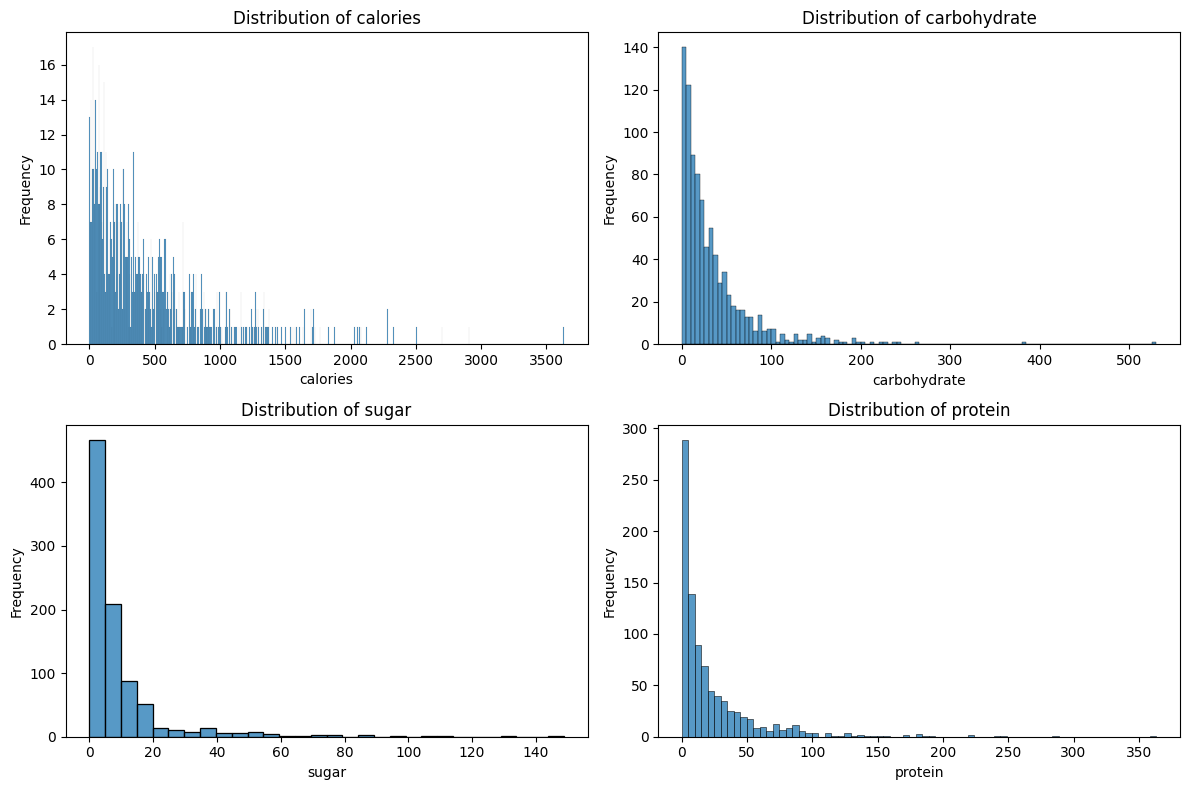

In [73]:
numeric_cols = [col for col in raw_data.columns if raw_data[col].dtype in ['int64', 'float64'] and col != 'recipe']

# Calcular filas necesarias: (total columnas / 2 columnas por fila), redondeado hacia arriba
rows = math.ceil(len(numeric_cols) / 2)

plt.figure(figsize=(12, rows * 4)) 
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 2, i) 
    sns.histplot(data = raw_data, x = col, binwidth=5)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The distributions of calories and carbohydrates exhibit the greatest dispersion, with a wide spread of values and long right tails. This suggests the presence of highly skewed distributions and potential extreme observations.

Sugar and protein follow a similar pattern, although with slightly more concentrated ranges, indicating variability across nutritional profiles.

## Exploring Numerical Data

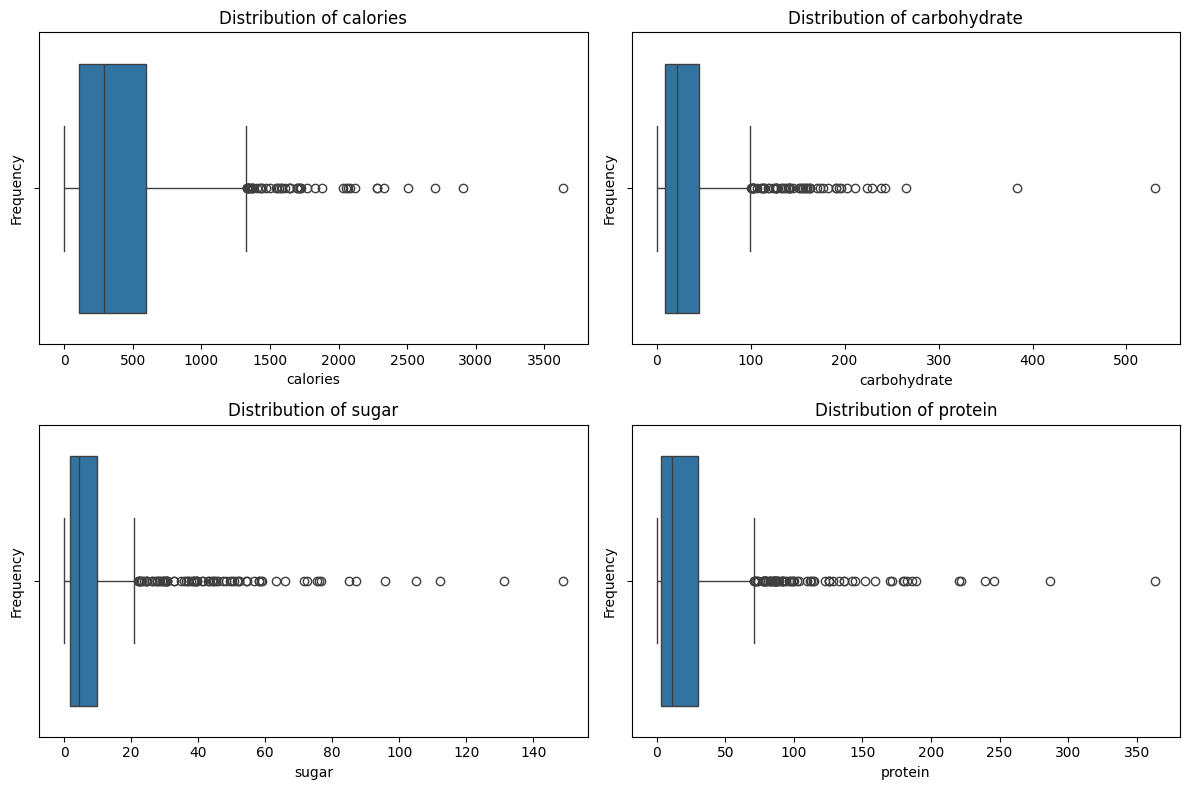

In [75]:
numeric_cols = [col for col in raw_data.columns if raw_data[col].dtype in ['int64', 'float64'] and col != 'recipe']
# raw_data.select_dtypes(include='number').columns

rows = math.ceil(len(numeric_cols) / 2)

plt.figure(figsize=(12, rows * 4)) 
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 2, i) 
    sns.boxplot(data = raw_data, x = col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [76]:
raw_data[['sugar', 'protein', 'carbohydrate', 'calories']].agg(['min', 'median', 'max', 'std'])
# raw_data.agg({'sugar': ['mean, ''std'], 'protein':['median']})
# raw_data.groupby('category').agg(mean_protein = ('protein', 'mean'))

,sugar,protein,carbohydrate,calories
min,0.010000,0.000000,0.030000,0.140000
median,4.550000,10.800000,21.480000,288.550000
max,148.750000,363.360000,530.420000,3633.160000
std,14.679176,36.369739,43.949032,453.020997


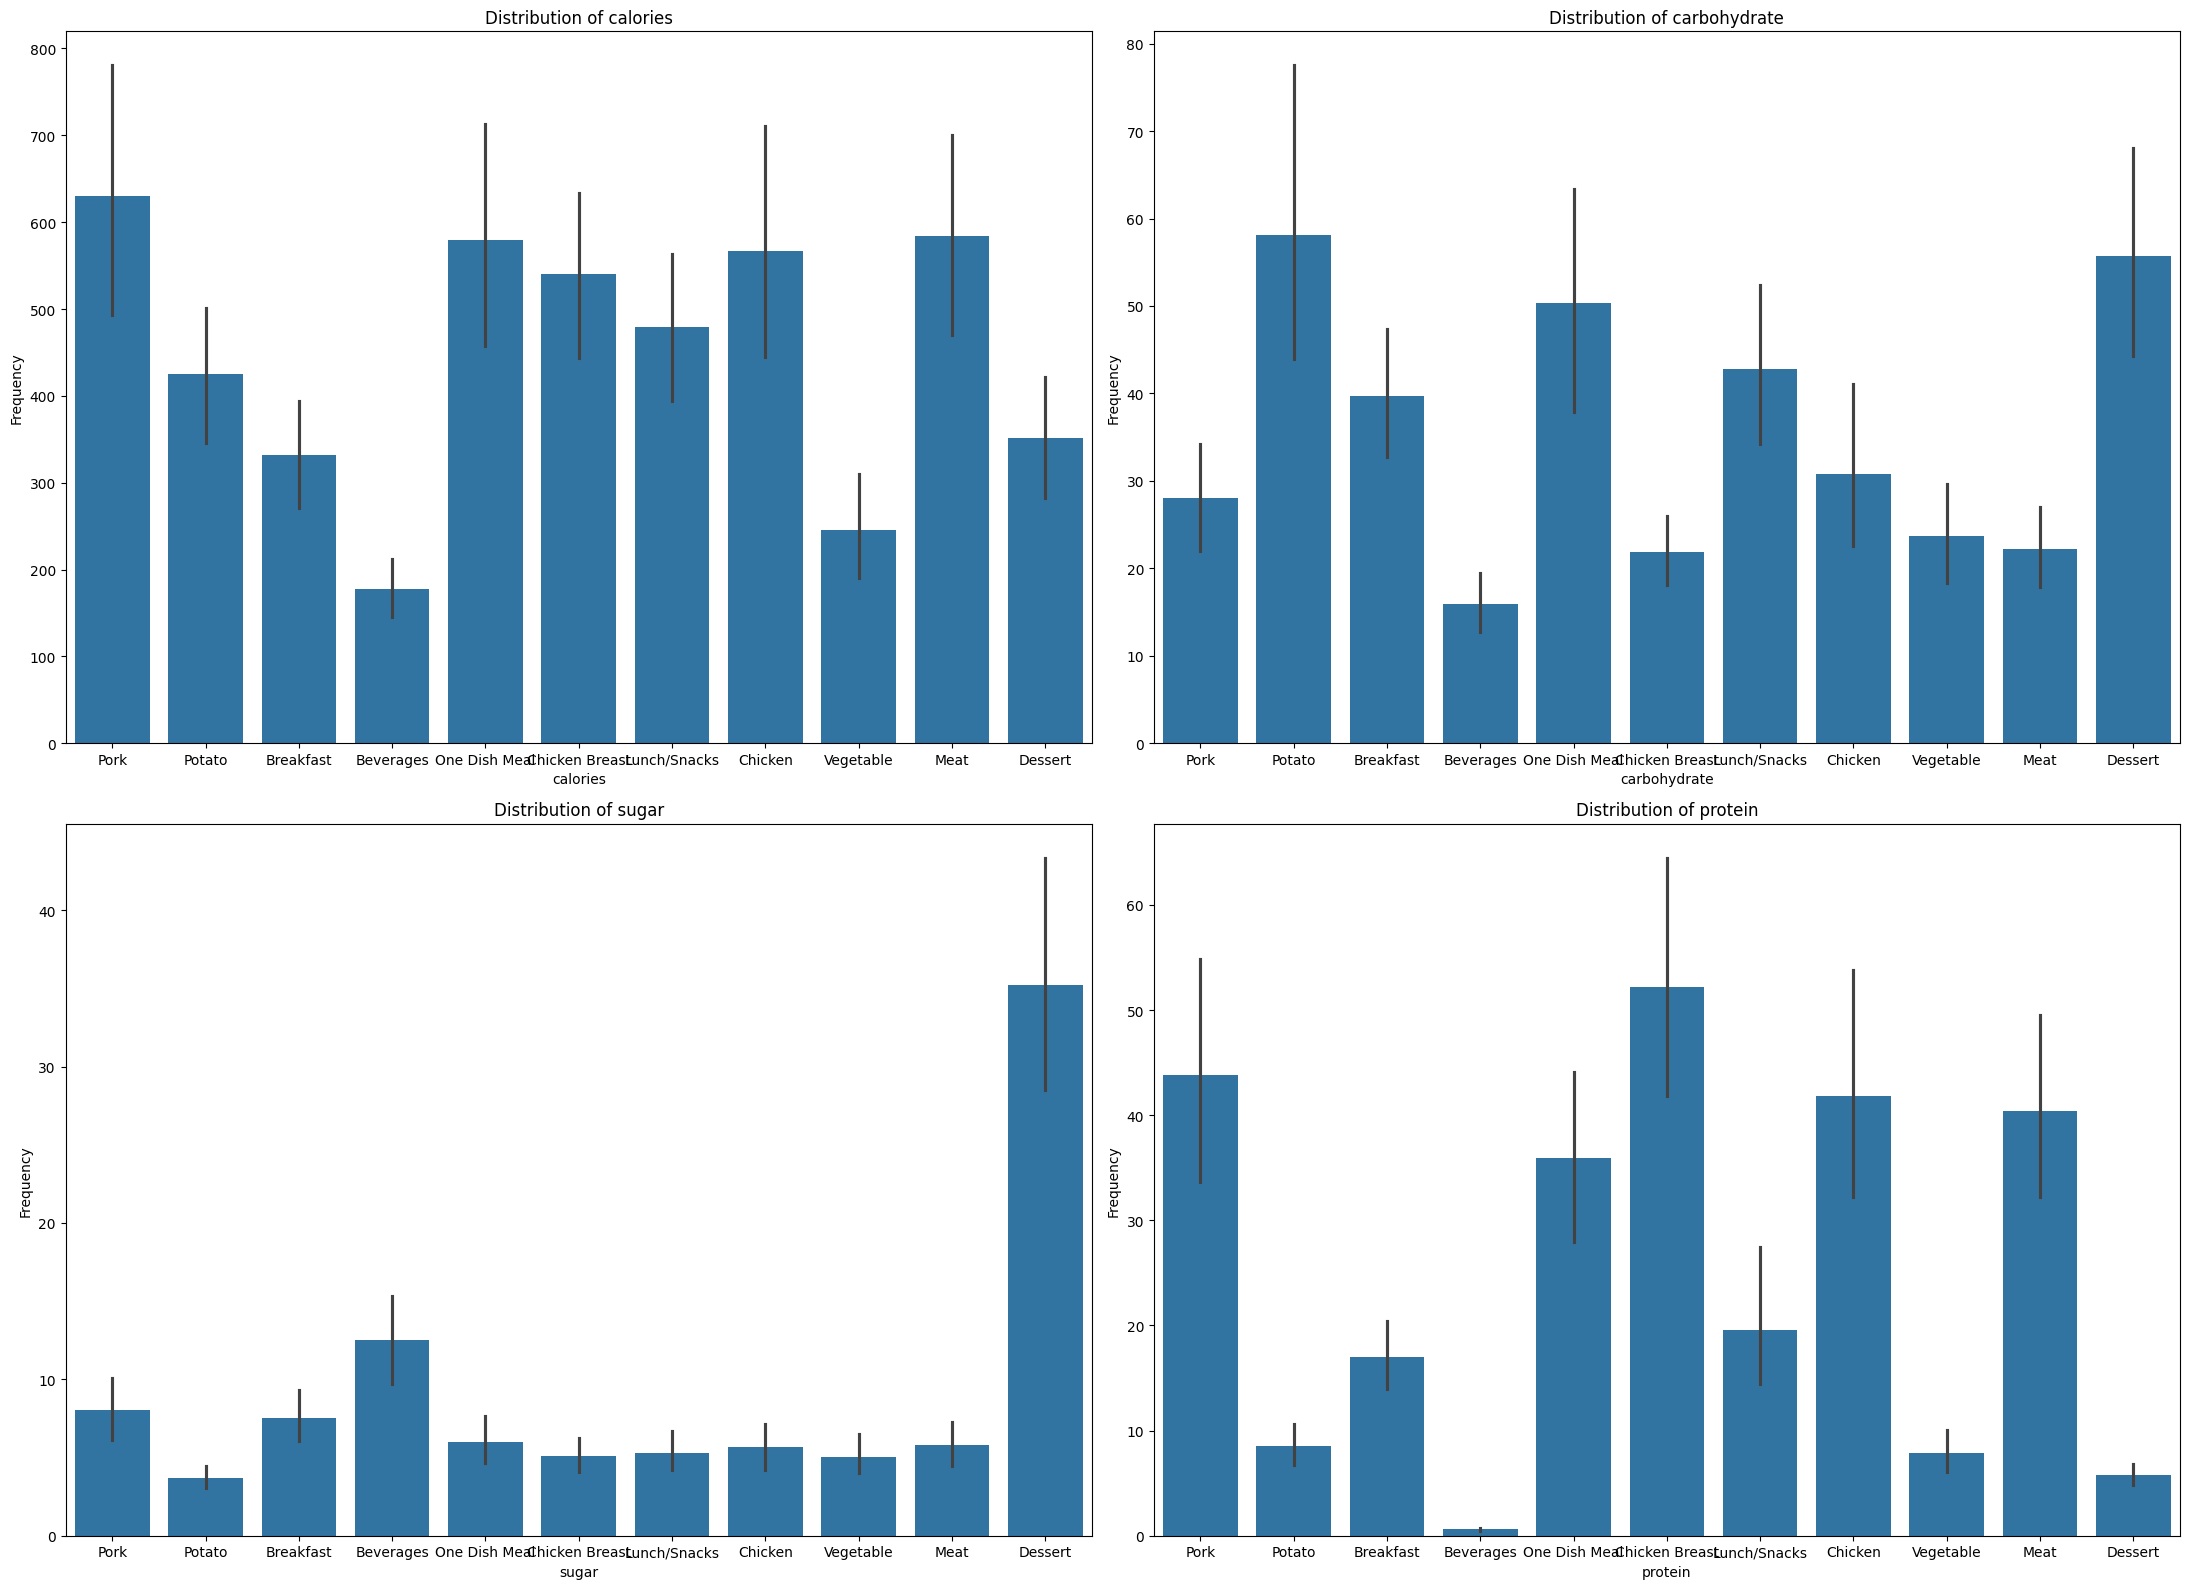

In [77]:
rows = math.ceil(len(numeric_cols) / 2)

plt.figure(figsize=(22, rows * 8)) # Ajustar altura según filas
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 2, i) # Filas dinámicas, 2 columnas
    sns.barplot(data=raw_data, x = 'category', y = col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Distributional Characteristics of Nutritional Variables

The summary statistics provide a clear indication of the underlying distributional patterns in the data. In particular, there is a substantial gap between the median and maximum values across all variables:

- Sugar: 4.55 vs 148.75  
- Protein: 10.8 vs 363.36  
- Carbohydrates: 21.48 vs 530.42  
- Calories: 288.55 vs 3633.16  

This pronounced disparity suggests that all variables exhibit strongly right-skewed distributions. In other words, most observations are concentrated at relatively low values, while a smaller number extend toward very high levels.

Such behavior is typical in food-related datasets, where the majority of items fall within moderate nutritional ranges, while a limited number exhibit significantly higher values.

To determine whether these extreme values represent valid observations or potential data quality issues, a formal outlier validation step will be conducted in the data validation section.

**These distributional patterns suggest that nutritional variables alone may not provide a clear separation between different types of recipes, reinforcing the need to analyze their relationship with the target variable in later stages.**

## Exploring Categorical Variables
In this section we will check whether the values in our object columns are limited, get the frequency of values in categoric columns and count how many unique values there are in each one.

In [78]:
# Inspect unique values for all categorical columns
categorical_cols = raw_data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(raw_data[col].unique())


Unique values in category:
['Pork' 'Potato' 'Breakfast' 'Beverages' 'One Dish Meal' 'Chicken Breast'
 'Lunch/Snacks' 'Chicken' 'Vegetable' 'Meat' 'Dessert']

Unique values in servings:
['6' '4' '1' '2' '4 as a snack' '6 as a snack']

Unique values in high_traffic:
['High' nan]


In [79]:
for i in categorical_cols:
    print('Frequency of', i,'data:\n',raw_data[i].value_counts(), '\n')


Frequency of category data:
 category
Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: count, dtype: int64 

Frequency of servings data:
 servings
4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: count, dtype: int64 

Frequency of high_traffic data:
 high_traffic
High    574
Name: count, dtype: int64 



In [80]:
# Since we already have an array with the name of categoric columns...
for i in categorical_cols:
    print('There are ',raw_data[i].nunique(), 'unique values in', i ,'column')

There are  11 unique values in category column
There are  6 unique values in servings column
There are  1 unique values in high_traffic column


Categorical variables were explored to assess the diversity and consistency of values across observations.

The `category` variable contains a well-defined set of groups, making it suitable for segmentation analysis. In contrast, the `servings` variable exhibits inconsistent formatting, combining numeric values with text (e.g., "4 as a snack"), indicating a data quality issue.

The target variable `high_traffic` contains missing values, suggesting incomplete labeling that will require careful handling in subsequent stages.

## Data Summarization

We can group the numerical data by a categorical variable,and explore combinations to uncover insights and valuable information, let's explore the characteristics of data subsets by grouping by a given category, which allows us to chain an aggregating function.

In [81]:
# We must add the categorical column to the subset
raw_data[['category', 'sugar', 'carbohydrate', 'protein']].groupby('category').mean()

,sugar,carbohydrate,protein
category,,,
Beverages,12.537283,15.955978,0.594783
Breakfast,7.552264,39.711698,16.957170
Chicken,5.678261,30.751304,41.843913
Chicken Breast,5.098723,21.833191,52.161383
Dessert,35.228442,55.661818,5.759870
Lunch/Snacks,5.309146,42.820976,19.610976
Meat,5.813649,22.159595,40.377027
One Dish Meal,6.011642,50.383433,35.926418
Pork,8.040137,28.076164,43.797671


Grouping the data by category reveals meaningful differences in nutritional composition across food types. Certain categories tend to exhibit higher average values in specific nutritional variables, suggesting structural variation within the dataset.

These aggregated patterns provide useful context for understanding how recipe characteristics differ across segments and may influence traffic performance.

# Data Validation
The purpose of this section is to assess the quality, consistency, and reliability of the dataset before proceeding to data cleaning and modeling.

While exploratory data analysis focuses on identifying patterns and distributions, data validation ensures that the data is accurate, complete, and logically consistent. The following checks are performed:
- Missing data assessment
- Duplicate detection
- Numerical validation (ranges and outliers)
- Categorical validation
- Logical consistency checks

## Missing Data Assessment

In [84]:
# Missing values summary
missing_summary = raw_data.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:")
print(missing_summary)

thres = len(raw_data) * 0.05
print(thres)

# Percentage of missing values
missing_percentage = (
    raw_data.isnull().mean() * 100
).round(2)
print("Percentage of missing values per columns:\n", missing_percentage[missing_percentage > 0])



Columns with missing values:
calories         52
carbohydrate     52
sugar            52
protein          52
high_traffic    373
dtype: int64
47.35
Percentage of missing values per columns:
 calories         5.49
carbohydrate     5.49
sugar            5.49
protein          5.49
high_traffic    39.39
dtype: float64


The dataset contains missing values in several variables. Nutritional features (calories, carbohydrate, sugar, and protein) each contain 52 missing values, representing approximately 5.49% of the dataset.

In contrast, the target variable `high_traffic` contains a substantially higher proportion of missing values (39.39%), which requires careful handling due to its importance in modeling.

A common rule of thumb suggests that when missing values represent a small proportion of the dataset (typically around 5%), removing affected observations may be acceptable. However, in this case, missing values are concentrated in key numerical variables, making row-wise deletion undesirable due to potential information loss.

Therefore, imputation strategies will be applied during the data cleaning stage to preserve dataset size while maintaining statistical integrity. 

Given the strong right-skewed distributions observed during the exploratory analysis, **the median is preferred over the mean for imputation**. The median is more robust to extreme values and prevents distortion of the central tendency.

Additionally, since missing values represent a relatively small proportion of the dataset (5.49% for nutritional variables), median imputation is unlikely to significantly alter the overall distribution of the data.

This approach ensures that statistical properties are preserved while avoiding unnecessary data loss.

## Duplicate Detection

In [85]:
raw_data.duplicated().sum()

np.int64(0)

No duplicate records were identified in the dataset, indicating that each observation represents a unique recipe. Therefore, no action is required regarding duplicate removal.

## Numerical Validation (ranges + outliers)

In [86]:
(raw_data[['calories','carbohydrate','sugar','protein']] < 0).sum()

calories        0
carbohydrate    0
sugar           0
protein         0
dtype: int64

Range checks confirm that no negative values are present in the numerical variables, indicating that all observations fall within acceptable logical bounds.

To assess the presence of extreme values, boxplots and summary statistics were analyzed. All variables exhibit right-skewed distributions, with maximum values significantly exceeding the median.

To determine whether these extreme values represent valid observations, the domain context of the dataset was considered. Since the data represents food recipes, high values in calories and macronutrients are plausible and may correspond to specific types of meals, such as high-calorie dishes or combination meals.

**Therefore, these extreme values are not treated as outliers in the context of data quality issues, but rather as valid observations reflecting the natural variability of the dataset. No transformation or removal is applied.**

These findings confirm that extreme values are structurally consistent with the domain and do not represent data entry errors. Therefore, no outlier treatment (such as removal or winsorization) is applied, preserving the natural variability of the dataset.

## Categorical Validation

In [87]:
for col in categorical_cols:
    print(raw_data[col].unique())

['Pork' 'Potato' 'Breakfast' 'Beverages' 'One Dish Meal' 'Chicken Breast'
 'Lunch/Snacks' 'Chicken' 'Vegetable' 'Meat' 'Dessert']
['6' '4' '1' '2' '4 as a snack' '6 as a snack']
['High' nan]


Categorical variables were examined to ensure consistency and validity of values.

The `category` variable contains a well-defined set of distinct groups with no apparent inconsistencies.

However, the `servings` variable presents inconsistent formatting, combining numeric values with text (e.g., "4 as a snack"), indicating the need for transformation into a standardized numeric format.

The target variable `high_traffic` contains missing values and a single observed explicit category ("High"). This indicates that missing values likely represent the absence of high traffic rather than missing information, which will be addressed during the data cleaning stage by defining a complete binary target variable.


## Logical Consistency Checks

In [141]:
print('Recipes with zero calories:', (raw_data['calories'] == 0).sum())
print('Recipes with zero servings:', (raw_data['servings'] == '0').sum())
print((raw_data['servings'].isna()).sum())

Recipes with zero calories: 0
Recipes with zero servings: 0
0


Logical validation checks were performed to ensure that key variables contain plausible values.

No records were found with zero servings or zero calories, indicating that the dataset does not contain clearly invalid entries in these dimensions.

These checks confirm that the data is logically consistent and suitable for further processing.

Additionally, no missing values were detected in the `servings` variable, confirming that inconsistencies in this column are related to formatting rather than data absence.


In [142]:
(raw_data[['calories','carbohydrate','sugar','protein']].sum(axis=1) == 0).sum()

np.int64(52)

A cross-variable consistency check identified 52 observations where all nutritional variables are simultaneously missing. This indicates that missing values are not randomly distributed but occur in complete blocks across related variables.

This pattern suggests that the missingness may be structural (e.g., incomplete records) rather than isolated data entry errors. These observations will be handled during the imputation stage to preserve dataset integrity.

### Key Observations

The validation process revealed several important data quality considerations:

* Nutritional variables (calories, carbohydrate, sugar, protein) contain missing values, including cases where all nutritional information is simultaneously absent, suggesting structured missingness.
* The `servings` column stores numeric information as text, indicating a data type inconsistency that requires standardization.
* The `category` variable contains well-defined groups and will require encoding for modeling purposes.
* The target variable `high_traffic` contains a high proportion of missing values and requires careful reinterpretation to construct a complete binary classification target.
* No duplicate records were identified, and all numerical values fall within acceptable logical ranges.

These findings support the need for a structured data cleaning process to ensure the dataset is consistent, complete, and suitable for reliable modeling.

# Data Cleaning

Based on the data validation process, several data quality issues were identified and addressed. The following table summarizes the preprocessing decisions applied to each variable in order to produce an analysis-ready dataset.


To preserve data integrity, we keep the original dataset unchanged (raw_data) and create a working copy where all cleaning, transformations, and feature engineering steps are applied.

In [89]:
# Preserve original dataset
raw_data_backup = raw_data.copy()

# Create working dataset for cleaning and preprocessing
clean_data = raw_data.copy()

### Missing Value Treatment
Missing values in nutritional variables were imputed using the median. This approach was selected due to the presence of right-skewed distributions and extreme values, as identified during the validation stage. The median provides a robust measure of central tendency that is less sensitive to outliers compared to the mean.

In [90]:
nutrition_cols = ['calories','carbohydrate','sugar','protein']

for col in nutrition_cols:
    clean_data[col] = clean_data[col].fillna(clean_data[col].median())

### Categorical Encoding
The `category` variable was transformed using one-hot encoding to convert categorical values into a numerical format suitable for machine learning models.

Before applying one-hot encoding, a copy of the original `category` variable is preserved as `categories`.

This step is necessary because one-hot encoding transforms the original categorical variable into multiple binary columns, effectively removing the original feature.

Keeping a copy allows for easier interpretation during exploratory analysis and post-cleaning analysis, particularly when visualizing relationships between recipe category and traffic outcomes.

In [ ]:
clean_data['categories'] = clean_data['category']
clean_data = pd.get_dummies(clean_data, columns=['category'])

### Servings Standardization
The `servings` variable contained numeric information stored as text, including inconsistent formats (e.g., "4 as a snack"). Numeric values were extracted and converted into a new variable `servings_num`, ensuring consistency and enabling quantitative analysis.

In [145]:
clean_data['servings_num'] = (
    clean_data['servings']
    .str.extract('(\d+)')
    .astype(float)
)
clean_data['servings_num'].isna().sum()


np.int64(0)

After extraction, the `servings_num` variable was validated to ensure successful conversion from text to numeric format. No missing values were introduced during this process, confirming the robustness of the transformation.


### Binary target variable
The `high_traffic` variable contained missing values and was stored as a categorical field.

Before encoding the target variable, categorical values were standardized to ensure consistency in formatting (e.g., removing extra spaces and normalizing capitalization).

Missing values were then handled by assigning them to the "Low" category.

The assumption that missing values correspond to "Low" traffic is supported by the data structure, where only high-performing recipes are explicitly labeled. This transformation ensures a complete and interpretable binary target variable while preserving the dataset size.

Before encoding the target variable, categorical values were standardized to ensure consistency in formatting (e.g., removing extra spaces and normalizing capitalization). This step prevents multiple representations of the same category, such as "high", " High", or "HIGH".

Finally, the variable was encoded into a binary format (`high_traffic_flag`), where:
- 1 represents "High"
- 0 represents "Low"

This transformation ensures compatibility with classification models.

In [93]:
# Standardize text format first
clean_data['high_traffic'] = (
    clean_data['high_traffic']
    .str.strip()
    .str.capitalize()
)

# Handle missing values
clean_data['high_traffic'] = clean_data['high_traffic'].fillna('Low')

# Encode target variable
clean_data['high_traffic_flag'] = clean_data['high_traffic'].map({
    'High': 1,
    'Low': 0
})

### Post-Cleaning Validation

After applying the preprocessing steps, the dataset was re-evaluated to ensure data quality.

Post-cleaning validation confirms that all missing values have been successfully addressed, no unintended missing values were introduced during transformations, and all variables are consistent with their intended formats.

This ensures that the dataset is fully prepared for reliable statistical analysis and machine learning modeling.

In [94]:
# Validation
clean_data.isna().sum()

recipe                     0
calories                   0
carbohydrate               0
sugar                      0
protein                    0
servings                   0
high_traffic               0
categories                 0
category_Beverages         0
category_Breakfast         0
category_Chicken           0
category_Chicken Breast    0
category_Dessert           0
category_Lunch/Snacks      0
category_Meat              0
category_One Dish Meal     0
category_Pork              0
category_Potato            0
category_Vegetable         0
servings_num               0
high_traffic_flag          0
dtype: int64

In [143]:
clean_data.dtypes

recipe                       int64
calories                   float64
carbohydrate               float64
sugar                      float64
protein                    float64
servings                    object
high_traffic                object
categories                  object
category_Beverages            bool
category_Breakfast            bool
category_Chicken              bool
category_Chicken Breast       bool
category_Dessert              bool
category_Lunch/Snacks         bool
category_Meat                 bool
category_One Dish Meal        bool
category_Pork                 bool
category_Potato               bool
category_Vegetable            bool
servings_num               float64
high_traffic_flag            int64
dtype: object

Data types were re-evaluated after preprocessing to ensure that all variables are in formats suitable for analysis. Numerical variables are correctly stored as numeric types, and encoded categorical variables are represented in a machine-readable format.


### Data Cleaning Summary

| Column | Data Type | Issue Identified | Action Taken | Rationale |
|-------|-----------|------------------|-------------|-----------|
| recipe | int64 | No data quality issues | No transformation applied | Serves as unique identifier; not used as predictive feature |
| calories | float64 | Missing values (52 rows) | Median imputation | Robust to skewed distributions and extreme nutritional values |
| carbohydrate | float64 | Missing values | Median imputation | Preserves dataset size while reducing sensitivity to outliers |
| sugar | float64 | Missing values | Median imputation | Nutritional variables typically show right-skewed behavior |
| protein | float64 | Missing values | Median imputation | Prevents information loss without distorting central tendency |
| category | object | Categorical variable | One-Hot Encoding | Required numerical representation for machine learning models |
| servings | object | Numeric information stored as text | Extracted numeric values into `servings_num` | Standardizes variable for quantitative analysis |
| high_traffic | object | Missing labels and target not numeric  | Missing values labeled as "Low" and encoded as binary | Ensures complete target definition for classification modeling |

# Post-Cleaning Analysis: Feature Relationships and Insights

After data cleaning, the dataset is analyzed to understand the relationships between features and their association with traffic outcomes. This step focuses on identifying patterns that may provide predictive signals for modeling.


## Nutritional Distributions by Traffic Outcome

Using Seaborn allows clearer comparison between high-traffic and low-traffic recipes, helping identify whether certain nutritional patterns are associated with increased platform interaction.

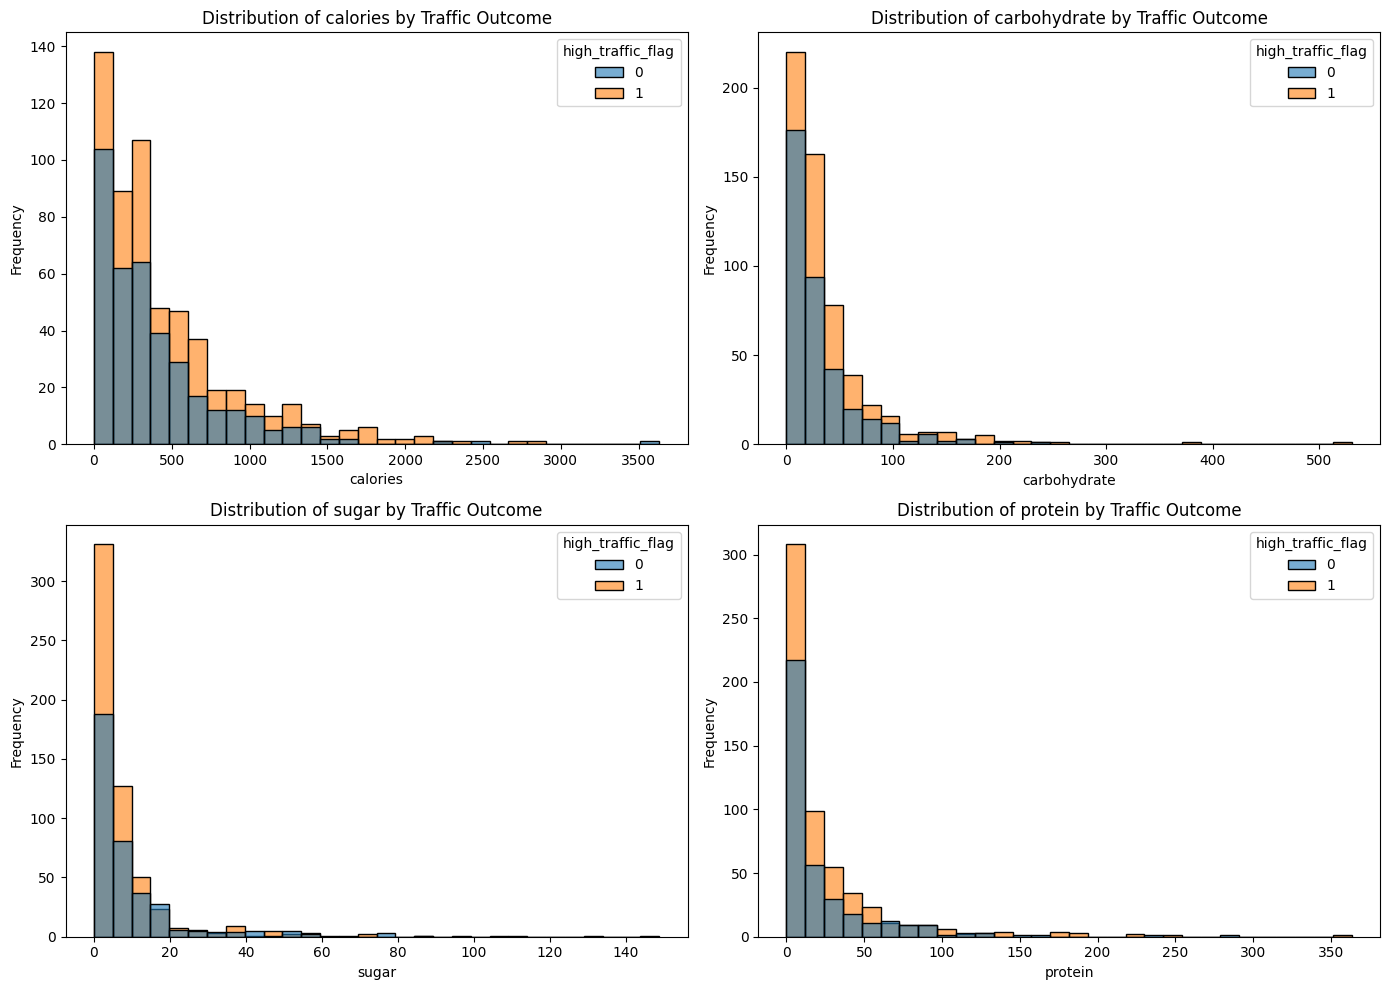

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['calories', 'carbohydrate', 'sugar', 'protein']

plt.figure(figsize=(14,10))

for i, col in enumerate(features, 1):
    
    plt.subplot(2,2,i)
    
    sns.histplot(
        data=clean_data,
        x=col,
        hue='high_traffic_flag',
        bins=30,
        kde=False,
        alpha=0.6
    )
    
    plt.title(f'Distribution of {col} by Traffic Outcome')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

To better understand the relationship between nutritional characteristics and user engagement, the distributions of key numerical variables were analyzed by traffic outcome.

The comparison shows that both high-traffic and low-traffic recipes share broadly similar distribution shapes, with most observations concentrated in lower value ranges.

However, the lack of clear separation between the two groups suggests that individual nutritional variables alone have limited predictive power. This indicates that traffic performance is likely influenced by interactions between features rather than isolated effects.

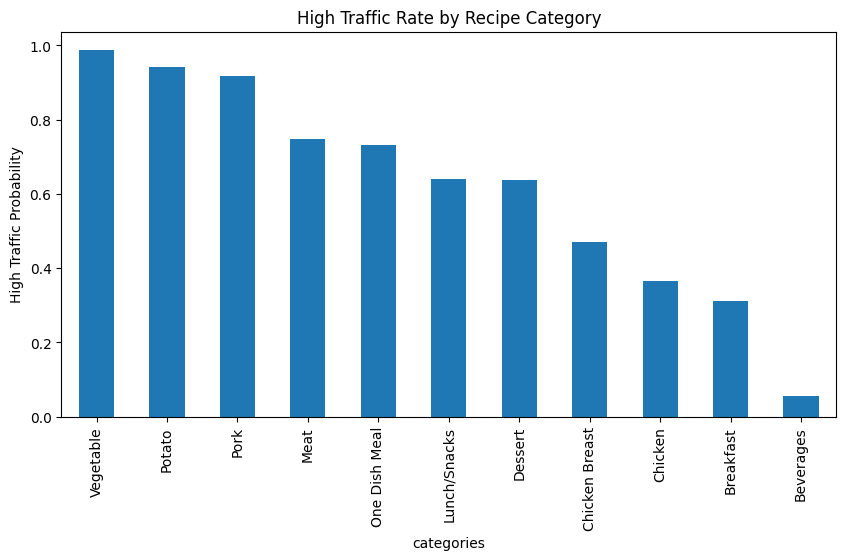

In [96]:
traffic_rate = (
    clean_data
    .groupby('categories')['high_traffic_flag']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
traffic_rate.plot(kind='bar')
plt.title('High Traffic Rate by Recipe Category')
plt.ylabel('High Traffic Probability')
plt.show()


**Traffic Rate by Category**

The variation in high-traffic rates across categories indicates that certain types of recipes are more likely to attract user engagement. This suggests that category is a relevant predictor and may capture underlying user preferences.

However, since no category exclusively determines traffic outcome, its predictive power is likely enhanced when combined with other features.


## Nutritional Feature Relationships

Before building predictive models, it is essential to understand how the main numerical variables interact with each other and how they relate to traffic performance.

The following pairplot provides a multivariate visual exploration of the dataset, allowing us to simultaneously analyze:

- The distribution of each nutritional feature
- Potential correlations between variables
- Structural patterns associated with recipe popularity
- The separation (or overlap) between high-traffic and non-high-traffic recipes

This step is part of the Exploratory Data Analysis (EDA) process and helps identify underlying behavioral patterns in user preferences before introducing any machine learning assumptions.

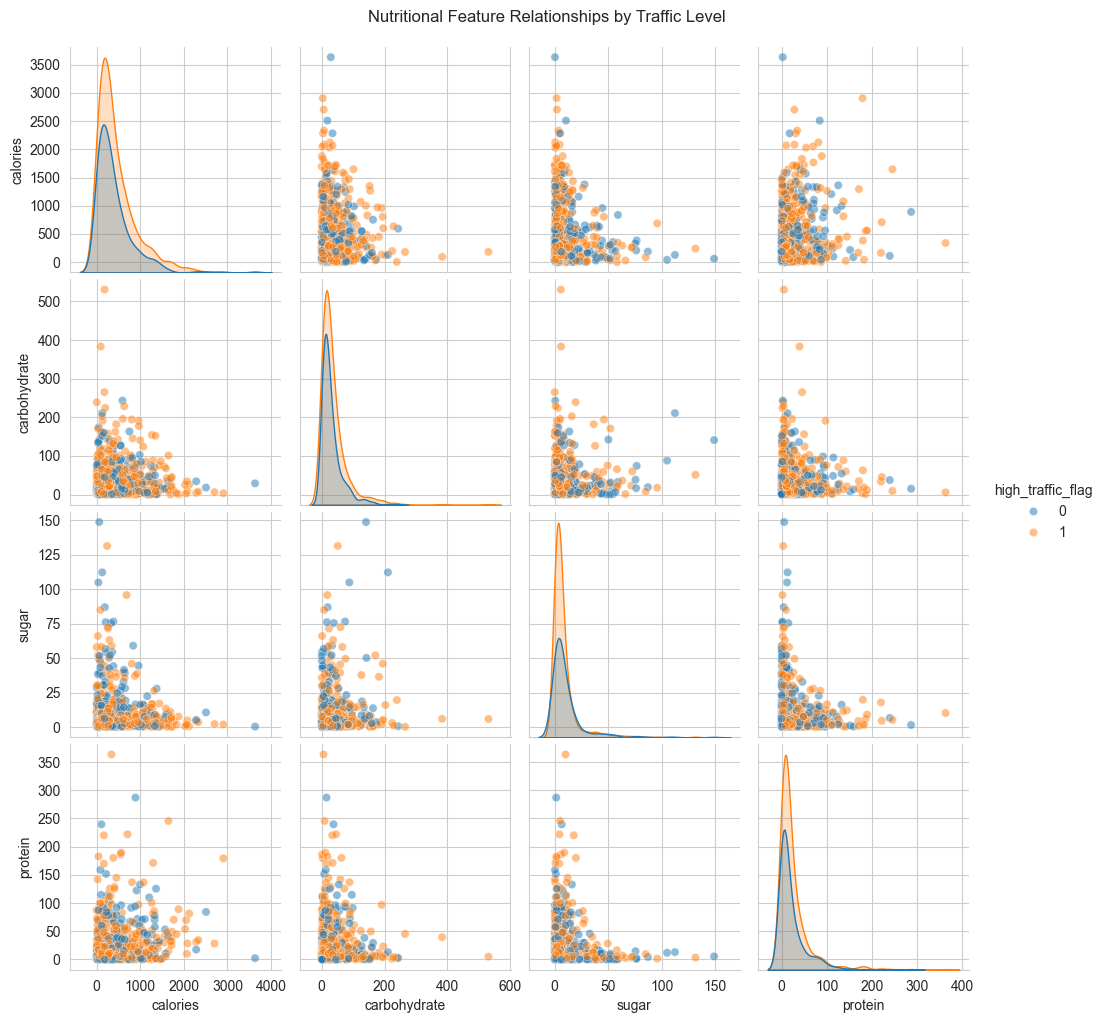

In [146]:
sns.set_style("whitegrid")

# Variables numéricas
num_cols = ['calories', 'carbohydrate', 'sugar', 'protein']

# Pairplot colored by traffic level
sns.pairplot(
    clean_data,
    vars=num_cols,
    hue='high_traffic_flag',
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

plt.suptitle(
    "Nutritional Feature Relationships by Traffic Level",
    y=1.02
)

plt.show()

### Key Observations

The pairplot provides a multivariate view of the relationships between nutritional variables and traffic outcomes.

1. **Right-skewed nutritional distributions**
   Most nutritional variables (calories, carbohydrates, sugar, and protein) show strong right skewness, indicating that the majority of recipes are relatively light, while a smaller group contains very high nutritional values.

2. **Weak linear relationships between features**
   The scatter plots suggest limited linear correlation between nutritional variables. This indicates that recipe performance is unlikely to depend on a single nutritional dimension alone.

3. **High concentration in lower nutritional ranges**
   A large density of observations appears in lower calorie and lower sugar regions, suggesting that typical platform content is centered around moderate nutritional profiles.

4. **No clear visual separation for high traffic**
   High-traffic recipes do not form a clearly separable cluster based solely on nutritional features. This suggests that traffic performance is influenced by nonlinear interactions or additional factors such as category, presentation, or user behavior.

### Implication for Modeling

Because patterns are not linearly separable, more flexible models (such as gradient boosting or tree-based methods) are appropriate for capturing complex relationships between nutritional composition and traffic outcomes.

**This insight directly motivates the use of XGBoost in the subsequent modeling phase but we will corroborate if this suggestion is correct.**

### Categorical Relationships with Traffic Outcome

To further understand how categorical features relate to user engagement, the distribution of recipe categories is analyzed with respect to traffic outcome.

This allows us to identify whether certain categories are more strongly associated with high or low traffic levels.

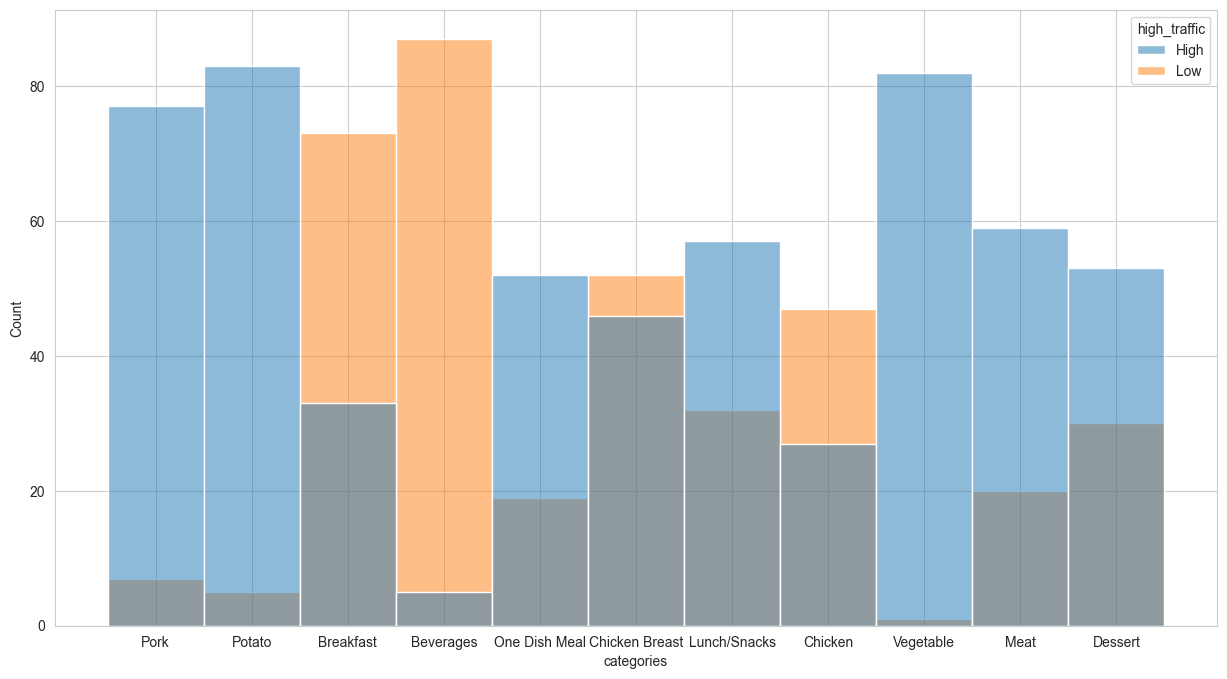

In [98]:
clean_data.select_dtypes(include='object').columns
plt.figure(figsize=(15, rows * 4))
sns.histplot(data = clean_data, x = 'categories', hue = 'high_traffic', binwidth=1)
plt.show()


### Key Observations

The distribution shows that traffic is not evenly distributed across categories. Some categories appear to have a higher concentration of high-traffic recipes, while others are more associated with low-traffic outcomes.

This indicates that category plays a meaningful role in user engagement and may provide predictive value in distinguishing high-performing recipes.

However, no single category exclusively determines traffic outcome, suggesting that category alone is not sufficient to explain performance and should be considered alongside other features.

## Final Insights for Modeling

The exploratory analysis indicates that no single feature provides a clear separation between high-traffic and low-traffic recipes. Instead, patterns emerge from the interaction between multiple variables, particularly between category and nutritional composition.

This reinforces the need for flexible modeling approaches capable of capturing nonlinear relationships and feature interactions.

Therefore, tree-based models such as XGBoost are appropriate candidates for this problem, as they can effectively model complex structures without requiring strict assumptions about linearity.


# MODEL
But how can we be sure with the watched in the EDA that the insights directly motivates the use of XGBoost in the subsequent modeling phase.

We can make a fast compasition to extract information from the dataset and prove that the best model to use is the XGBoost model, using and comparing the workflow with the logsitic model and XGB model...

In [101]:
# Target
y = clean_data['high_traffic_flag']

# Features
X = clean_data.drop(columns=[
    'recipe',
    'high_traffic',
    'high_traffic_flag',
    'servings',
    'categories'
])
X = X.astype(int) # We ensure that we are working with numeric data, this is better for the Logistic Model

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Logistic 

## Predictive Modeling: Logistic Regression Baseline (Nutritional Features Only)

## What nutritional signals appear associated with high traffic when contextual information is unknown?

After completing data validation and preprocessing, the first modeling step focuses on understanding how recipes behave when only their nutritional profile is considered. The objective of this baseline model is not to capture the full complexity of user behavior, but to isolate and evaluate whether nutritional characteristics alone contain predictive signals related to high traffic.
A Logistic Regression model was selected as an initial approach due to its interpretability and suitability for binary classification problems. Beyond prediction, this model allows direct interpretation of how each feature influences the probability of a recipe achieving high traffic.
The feature set includes five quantitative variables describing recipe composition and portion size:
calories, carbohydrate, sugar, protein, and servings_num.
The dataset was split into training and testing subsets using stratification to preserve the original class distribution. A preprocessing pipeline was applied to standardize numerical variables, ensuring coefficient comparability and stable model optimization.
The resulting coefficients provide directional insight into how nutritional attributes relate to user engagement in the absence of contextual information such as recipe type.


COEFFICIENTS: [[ 0.15880645  0.15998356 -0.10766082  0.03067051  0.10780978]]
INTERCEPT: [0.43761839]
        Feature  Coefficient  Odds_Ratio
1  carbohydrate     0.159984    1.173492
0      calories     0.158806    1.172111
4  servings_num     0.107810    1.113836
3       protein     0.030671    1.031146
2         sugar    -0.107661    0.897932


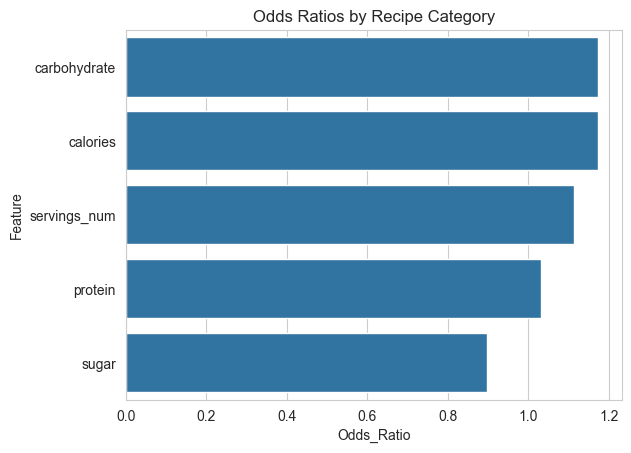

In [102]:
# Selecting features
X_nutritional = clean_data[['calories', 'carbohydrate', 'sugar', 'protein', 'servings_num']]
y_nutritional = clean_data['high_traffic_flag']

# Train-test split
X_train_nutritional, X_test_nutritional, y_train_nutritional, y_test_nutritional = train_test_split(
    X_nutritional, y_nutritional, test_size=0.3, random_state=42, stratify=y
)

# Pipeline (scaling + logistic regression)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(solver='lbfgs', max_iter=1000))
])

# Train model
pipeline.fit(X_train_nutritional, y_train_nutritional)

# Extract model
model = pipeline.named_steps['logistic']

print("COEFFICIENTS:", model.coef_)
print("INTERCEPT:", model.intercept_)

###################v##
# Get feature names
feature_names = X_nutritional.columns

# Get coefficients
coefficients = model.coef_[0]

# Create dataframe for readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute impact
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print(coef_df.sort_values(by='Odds_Ratio', ascending=False))

sns.barplot(data=coef_df, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Category")
plt.show()

The logistic regression results provide an initial view of how nutritional characteristics relate to high traffic probability:

* The model suggests that calories, carbohydrates, and serving size have a positive association with high traffic probability, indicating that larger and more energy-dense recipes may attract greater user engagement. 

* Protein shows only a marginal positive contribution, suggesting a weaker influence compared to other nutritional variables.

* Interestingly, over this features, sugar presents a negative coefficient despite exploratory visualizations suggesting a positive relationship. 

Overall, the model suggests that recipe popularity cannot be explained by a single nutritional factor but rather by the combined interaction among features.


## Motivation for Model Expansion
However, this analysis raises an important question:
## What happens when we incorporate contextual information about the recipe itself?
By excluding recipe categories, the model assumes that nutritional composition fully explains user behavior. 

In practice, this omission can introduce a confounding effect, where nutritional variables partially capture differences that actually belong to recipe type.

To address this limitation, a second model is developed incorporating recipe categories alongside nutritional attributes, allowing us to evaluate whether the observed nutritional effects remain stable once contextual information is considered.

In [103]:
# Train logistic regression
clf_logistic = LogisticRegression(max_iter=1000)
clf_logistic.fit(X_train, y_train)


# Predict probabilities
preds = clf_logistic.predict_proba(X_test)

# Compare predictions with true values
preds_df = pd.DataFrame(
    preds[:, 1][0:5],
    columns=['prob_high']
)

true_df = y_test.head(5).reset_index(drop=True)

print(pd.concat([true_df, preds_df], axis=1))

   high_traffic_flag  prob_high
0                  1   0.860309
1                  0   0.097750
2                  1   0.298158
3                  1   0.459544
4                  0   0.100008


                    Feature  Coefficient  Odds_Ratio
14       category_Vegetable     2.197351    9.001134
13          category_Potato     1.864722    6.454143
12            category_Pork     1.286870    3.621434
10            category_Meat     0.461280    1.586102
11   category_One Dish Meal     0.400405    1.492428
15             servings_num     0.032263    1.032789
2                     sugar     0.002599    1.002602
3                   protein     0.001316    1.001317
1              carbohydrate     0.001070    1.001070
0                  calories     0.000163    1.000163
9     category_Lunch/Snacks    -0.032330    0.968187
8          category_Dessert    -0.120025    0.886898
7   category_Chicken Breast    -0.841499    0.431064
6          category_Chicken    -1.092137    0.335499
5        category_Breakfast    -1.274316    0.279622
4        category_Beverages    -2.683450    0.068327


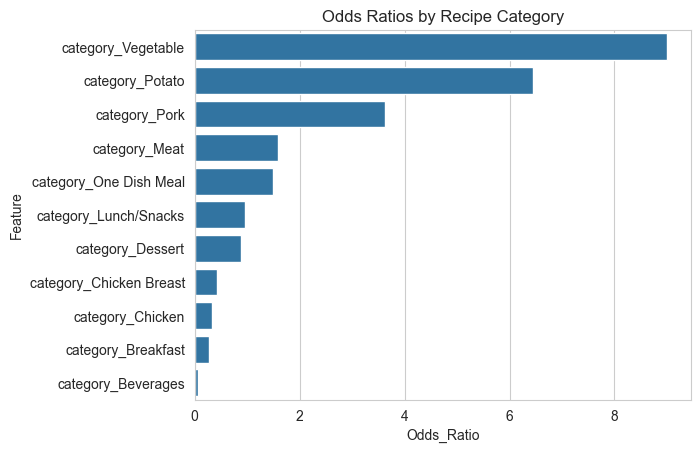

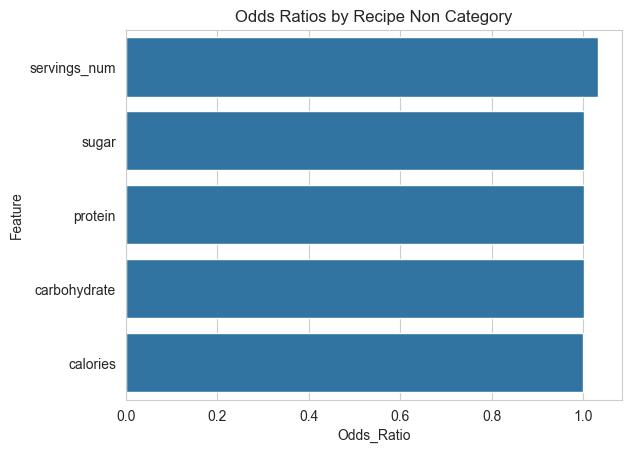

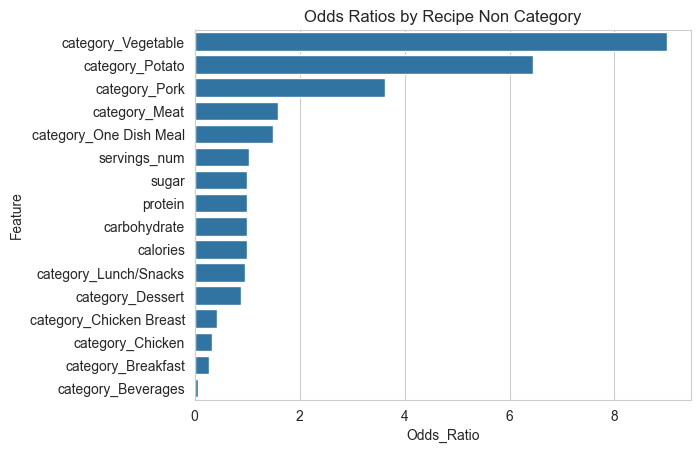

In [104]:
# Get feature names
feature_names = X.columns

# Get coefficients
coefficients = clf_logistic.coef_[0]

# Create dataframe for readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute impact
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# Odds ratio
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print(coef_df.sort_values(by='Odds_Ratio', ascending=False))

# Categorical features importance
cat_coef = coef_df[coef_df['Feature'].str.contains('category')]

sns.barplot(data=cat_coef, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Category")
plt.show()

# Non categorical features importance 
non_cat_coef = coef_df[~coef_df['Feature'].str.contains('category')]

sns.barplot(data=non_cat_coef, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Non Category")
plt.show()

# Entire information
sns.barplot(data=coef_df, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Non Category")
plt.show()

### Key observations
* Recipe type explains traffic far more than nutritional composition.
* Users choose what to eat, not nutritional macros.
* Within popular categories, nutritional characteristics help optimize engagement.

### Model Interpretation
Nutritional variables initially appeared to be important predictors of high traffic. However, after controlling for recipe category, their effects decreased substantially. This suggests that nutritional composition was partially acting as a proxy for recipe type rather than being a primary driver of user interest.

Once recipe categories were incorporated, the model showed that traffic behavior is mainly driven by content preference. Categories such as Vegetable and Potato significantly increase the probability of high traffic, while nutritional variables contribute only marginally when contextual information is considered.

This indicates a two-level behavioral pattern: 
**recipe category drives initial user attraction, whereas recipe characteristics — such as servings and nutritional attributes — play a secondary role by optimizing engagement within each category.**

In particular, recipes classified under the Vegetable category exhibit a substantially higher likelihood of generating high traffic. Holding other variables constant, vegetable recipes increase the odds of high engagement by approximately nine times relative to the baseline category, reinforcing that user interaction is primarily preference-driven rather than nutrition-driven.

## Marginal Feature Effect Analysis - PENDIENTE POR AÑADIR
After training the logistic regression model, an additional analysis was performed to better understand how each feature individually influences the predicted probability of a recipe achieving high traffic.

To isolate the marginal effect of each variable, partial probability curves were constructed by varying one feature across its observed range while keeping all other variables fixed at their median values. This controlled simulation allows the model response to be analyzed independently for each nutritional component, removing the influence of simultaneous feature variation.

This approach improves interpretability by translating model coefficients into intuitive probability changes, helping visualize how variations in nutritional composition affect predicted user engagement.

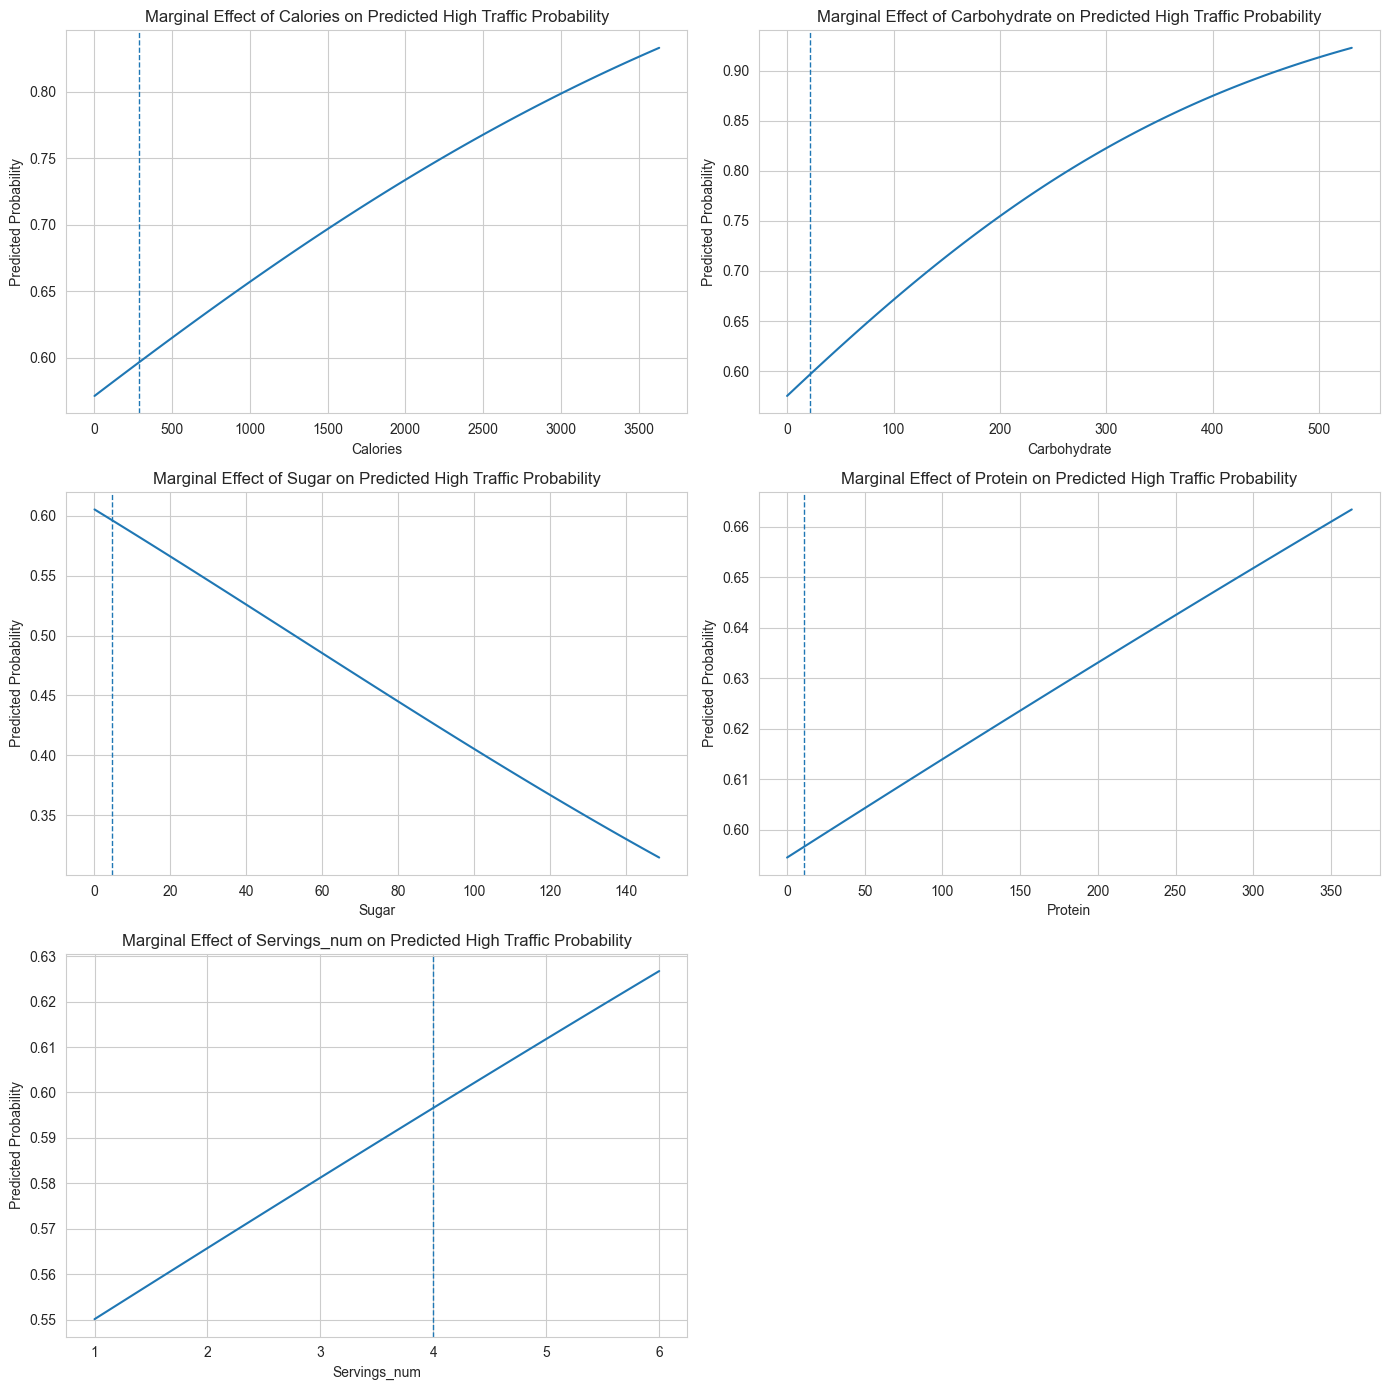

In [105]:
sns.set_style("whitegrid")
# sns.set_context("talk")

# Variables to analyze
features = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings_num']

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    
    # Range of values for simulation
    feature_range = np.linspace(
        clean_data[feature].min(),
        clean_data[feature].max(),
        100
    )
    
    # Simulation dataframe (others fixed at median)
    X_sim = pd.DataFrame({
        'calories': clean_data['calories'].median(),
        'carbohydrate': clean_data['carbohydrate'].median(),
        'sugar': clean_data['sugar'].median(),
        'protein': clean_data['protein'].median(),
        'servings_num': clean_data['servings_num'].median()
    }, index=range(100))
    
    # Vary only one feature
    X_sim[feature] = feature_range
    
    # Predict probabilities
    prob_high = pipeline.predict_proba(X_sim)[:, 1]
    
    # Plot marginal effect
    sns.lineplot(x=feature_range, y=prob_high, ax=axes[i])
    
    axes[i].set_title(
        f"Marginal Effect of {feature.capitalize()} on Predicted High Traffic Probability"
    )
    
    axes[i].set_xlabel(feature.capitalize())
    axes[i].set_ylabel("Predicted Probability")

    axes[i].axvline(
        clean_data[feature].median(),
        linestyle='--',
        linewidth=1
    )

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


The partial probability curves reveal clear directional relationships between nutritional characteristics and predicted traffic outcomes.

**Calories and carbohydrates show a strong positive and nonlinear increase in probability, suggesting that richer and more energy-dense recipes are more likely to attract user attention**. 
Serving size also presents a consistent positive effect, indicating that **recipes designed for larger portions may be perceived as more valuable or practical by users**.

Protein exhibits only a mild positive influence, reinforcing earlier findings that its contribution to traffic prediction is relatively limited compared to other nutritional variables.

In contrast, **sugar demonstrates a negative marginal effect, where higher sugar levels reduce the predicted probability of high traffic**. 
This behavior differs from some exploratory visual patterns and likely reflects multicollinearity between sugar and carbohydrate content, where the model attributes shared information primarily to carbohydrates.

Overall, these curves confirm that **recipe popularity emerges from a balance of nutritional attributes rather than a single dominant factor**. 

These results complement the exploratory analysis by confirming that relationships visually observed during EDA remain consistent when evaluated under a controlled multivariate framework. While exploratory plots show raw associations, the marginal effect analysis isolates each variable's contribution after accounting for the presence of other features in the model.

##  Model Performance
Let us see how the logistic models performace with this information with some tools as ACCURACY AND ROC CURVE

Logistic Accuracy: 0.7649122807017544
Logistic ROC-AUC: 0.8461498761354252


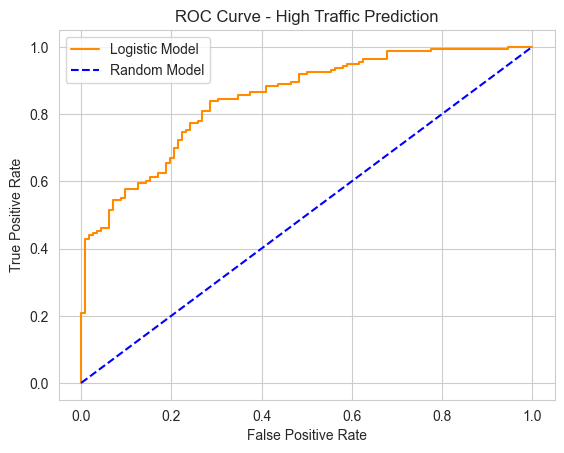

Logistic AUC: 0.8461498761354252


In [106]:
print("Logistic Accuracy:", accuracy_score(y_test, clf_logistic.predict(X_test)))
print("Logistic ROC-AUC:", roc_auc_score(y_test, preds[:,1]))

# Predict probabilities for positive class (High Traffic)
prob_high = clf_logistic.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, prob_high)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label='Logistic Model')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random Model')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Traffic Prediction")
plt.legend()
plt.show()

# Compute AUC
auc = roc_auc_score(y_test, prob_high)
print("Logistic AUC:", auc)

### Model Evaluation Results

- **ROC-AUC:** 0.846 → The model discriminates well between positive and negative classes.  
- **Accuracy:** 0.765 → Approximately 76.5% of predictions are correct.  
- **Interpretation:** The model shows strong class separation and reliable predictive performance, especially for imbalanced datasets where ROC-AUC is more informative than accuracy alone.


# Gradient Boosted Trees (XGBoost)
## We already analyze the Logistic model, now we move to a more advanced modeling approach.
**While Logistic Regression assumes a linear relationship between features and the log-odds of high traffic, real-world engagement behavior is often nonlinear and driven by complex feature interactions.**

To capture these patterns, we introduce:
Gradient Boosted Trees using XGBoost
Gradient Boosting builds multiple decision trees sequentially, where each new tree attempts to correct the errors of the previous ones. Instead of learning in a single step (as logistic regression does), the model improves iteratively.

This makes it particularly powerful for:
* Capturing nonlinear relationships
* Detecting feature interactions
* Handling mixed feature types
* Improving predictive performance

In [107]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Initialize model
clf_gbt = xgb.XGBClassifier()

# Train
clf_gbt.fit(X_train, y_train)

# Predict probabilities
gbt_preds_proba = clf_gbt.predict_proba(X_test)

# Compare first predictions
preds_df = pd.DataFrame(gbt_preds_proba[:,1][0:5], columns=['prob_high'])
true_df = y_test.head(5).reset_index(drop=True)

print(pd.concat([true_df, preds_df], axis=1))



   high_traffic_flag  prob_high
0                  1   0.983260
1                  0   0.058975
2                  1   0.425182
3                  1   0.254594
4                  0   0.007416


## Feature Importance 
Unlike logistic regression, which interprets feature importance through linear coefficients, XGBoost evaluates importance based on how frequently features are used to split decision trees.

The feature importance analysis reveals which variables most strongly influence high-traffic prediction. Variables that appear more frequently in tree splits contribute more significantly to the model’s decision process.

This analysis helps identify the structural drivers of recipe engagement and provides additional business insight beyond linear relationships.
To evaluate overall model performance, we rely on the F1-score, which balances precision and recall. Since correctly identifying high-traffic recipes is critical while avoiding excessive false positives, the F1-score provides a more comprehensive evaluation metric than accuracy alone.

{'calories': 400.0, 'carbohydrate': 343.0, 'sugar': 259.0, 'protein': 322.0, 'category_Beverages': 19.0, 'category_Breakfast': 24.0, 'category_Chicken': 21.0, 'category_Chicken Breast': 16.0, 'category_Dessert': 7.0, 'category_Lunch/Snacks': 24.0, 'category_Meat': 9.0, 'category_One Dish Meal': 6.0, 'category_Pork': 23.0, 'category_Potato': 22.0, 'category_Vegetable': 22.0, 'servings_num': 102.0}


<Figure size 640x480 with 0 Axes>

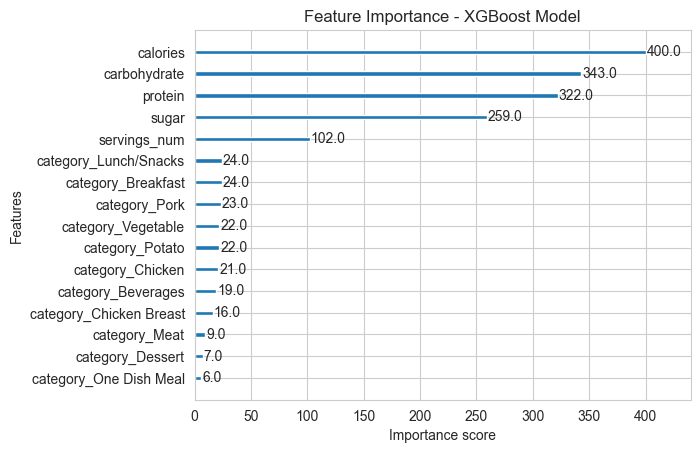

In [108]:
importance_dict = clf_gbt.get_booster().get_score(importance_type='weight')

print(importance_dict)


plt.figure()
xgb.plot_importance(clf_gbt, importance_type='weight')
plt.title("Feature Importance - XGBoost Model")
plt.show()

# Which model is better?
After completing the exploratory data analysis and preprocessing stages, the next step is to evaluate which modeling approach is more suitable for predicting high-traffic recipes.

In this section, two different models are explored:

* Logistic Regression, used as a transparent and interpretable baseline model.
* XGBoost, a tree-based ensemble method capable of capturing nonlinear relationships and complex feature interactions.

Both models will be compared using performance metrics, probability behavior, and feature importance analysis. This comparison allows us to understand not only predictive accuracy, but also how each model interprets the underlying data structure.

Based on insights obtained during the EDA — where relationships between nutritional variables and traffic outcomes showed limited linearity — the working hypothesis is that a nonlinear model such as XGBoost may better capture the patterns driving recipe performance.
The objective of this analysis is to select a single production model, balancing predictive performance, stability, and decision-making reliability.

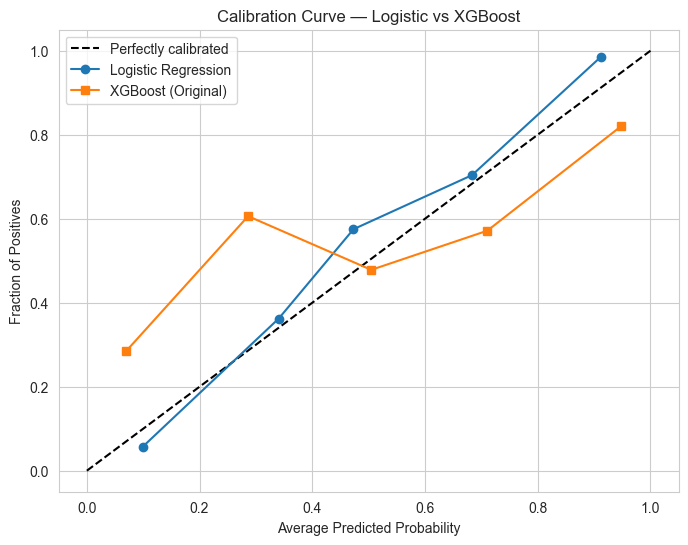

In [109]:
# XGBOOSTER MODEL
xgb_probs = clf_gbt.predict_proba(X_test)[:,1]

# VS

# LOGISTIC REGRESSION MODEL
log_probs = clf_logistic.predict_proba(X_test)[:,1]

# Calibration values
frac_log, mean_log = calibration_curve(y_test, log_probs, n_bins=5)
frac_gbt, mean_gbt = calibration_curve(y_test, xgb_probs, n_bins=5)

# Ploting outcomes
plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')

plt.plot(mean_log, frac_log, marker='o',
         label='Logistic Regression')

plt.plot(mean_gbt, frac_gbt, marker='s',
         label='XGBoost (Original)')

plt.xlabel("Average Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Logistic vs XGBoost")
plt.legend()

plt.show()

The calibration curve compares predicted probabilities with the observed frequency of high-traffic recipes. The diagonal line represents perfect calibration, where predicted probabilities match real outcomes.

Points above the identity line indicate that the model is underconfident, meaning the true proportion of high-traffic recipes is higher than what the model predicts. In contrast, points below the line indicate overconfidence, where the model assigns probabilities that are higher than the actual observed frequency.

From the figure, Logistic Regression follows the diagonal more closely at higher probability ranges, suggesting more reliable probability estimates. XGBoost, however, shows noticeable deviations from the identity line, particularly in mid-probability regions, indicating less calibrated probability outputs despite its predictive flexibility.

This result highlights an important distinction: strong predictive performance does not necessarily imply well-calibrated probabilities, which is critical when model outputs are used for decision-making and risk-based promotion strategies.

In [110]:
# Predict classes
gbt_preds = clf_gbt.predict(X_test)

target_names = ['Low Traffic', 'High Traffic']
print('XGBoost Classification Report:\n', classification_report(y_test, gbt_preds, target_names=target_names))

# clf_logistic
log_preds = clf_logistic.predict(X_test)

target_names = ['Low Traffic', 'High Traffic']
print('\n Logistic Classification Report:\n', classification_report(y_test, log_preds, target_names=target_names))

XGBoost Classification Report:
               precision    recall  f1-score   support

 Low Traffic       0.58      0.56      0.57       112
High Traffic       0.72      0.74      0.73       173

    accuracy                           0.67       285
   macro avg       0.65      0.65      0.65       285
weighted avg       0.67      0.67      0.67       285


 Logistic Classification Report:
               precision    recall  f1-score   support

 Low Traffic       0.68      0.75      0.71       112
High Traffic       0.83      0.77      0.80       173

    accuracy                           0.76       285
   macro avg       0.76      0.76      0.76       285
weighted avg       0.77      0.76      0.77       285



Logistic Accuracy: 0.7649122807017544
Logistic ROC-AUC: 0.8461498761354252


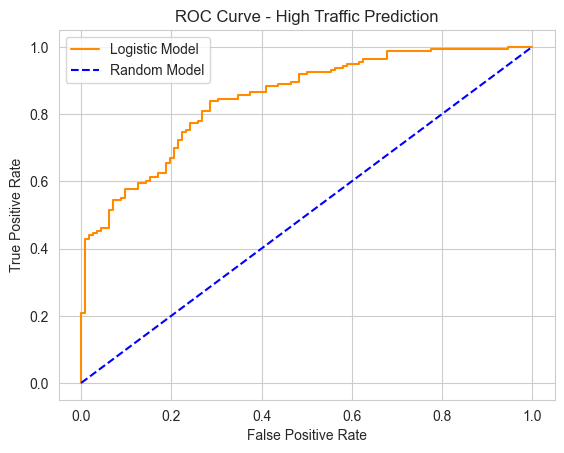

Logistic AUC: 0.8461498761354252
********* VS *********
XGBoost Accuracy: 0.6701754385964912
XGBoost ROC-AUC: 0.7623348472336912


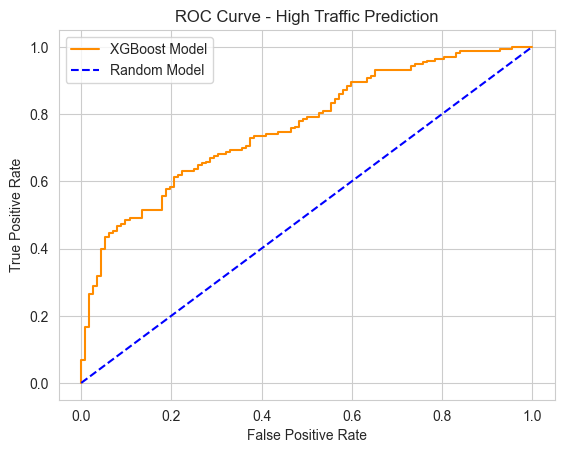

XGBoost AUC: 0.7623348472336912


In [111]:
log_preds = clf_logistic.predict_proba(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, clf_logistic.predict(X_test)))
print("Logistic ROC-AUC:", roc_auc_score(y_test, log_preds[:,1]))

# Predict probabilities for positive class (High Traffic)
log_prob_high = clf_logistic.predict_proba(X_test)[:, 1]

# Compute ROC curve
log_fpr, log_tpr, log_thresholds = roc_curve(y_test, log_prob_high)

# Plot ROC
plt.figure()
plt.plot(log_fpr, log_tpr, color='darkorange', label='Logistic Model')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random Model')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Traffic Prediction")
plt.legend()
plt.show()

# Compute AUC
auc = roc_auc_score(y_test, log_prob_high)
print("Logistic AUC:", auc)

print('********* VS *********')

gbt_preds = clf_gbt.predict_proba(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, clf_gbt.predict(X_test)))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, gbt_preds[:,1]))

# Predict probabilities for positive class (High Traffic)
gbt_prob_high = clf_gbt.predict_proba(X_test)[:, 1]

# Compute ROC curve
gbt_fpr, gbt_tpr, gbt_thresholds = roc_curve(y_test, gbt_prob_high)

# Plot ROC
plt.figure()
plt.plot(gbt_fpr, gbt_tpr, color='darkorange', label='XGBoost Model')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random Model')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Traffic Prediction")
plt.legend()
plt.show()

# Compute AUC
auc = roc_auc_score(y_test, gbt_prob_high)
print("XGBoost AUC:", auc)

## Conclutions
### Model Selection Conclusion

Although the exploratory data analysis suggested that several features did not exhibit a clear linear relationship with the target variable (a situation where non-linear models such as XGBoost are often expected to perform better) the empirical results indicate otherwise.

Based on the evaluation metrics:

- **Logistic Regression**
  - Accuracy: 0.765
  - ROC-AUC: 0.846
  - Stronger precision, recall, and F1-score across both classes
  - Better overall classification balance

- **XGBoost**
  - Accuracy: 0.670
  - ROC-AUC: 0.762
  - Lower predictive performance and weaker class discrimination

Despite the potential presence of non-linear relationships, Logistic Regression achieved superior discrimination ability, higher accuracy, and more stable classification performance. This suggests that the underlying signal in the data can still be effectively captured by a linear decision boundary, or that the dataset complexity is not sufficient for XGBoost to provide additional predictive advantage.

**Final Decision:**  
Logistic Regression is selected as the preferred model due to its better overall predictive performance, higher ROC-AUC, improved calibration behavior, and simpler interpretability.


# Hyperparameters
## Hyperparameter Tuning

Although Logistic Regression is a relatively simple and interpretable model,
its performance depends on the level of regularization applied.

To ensure the selected model generalizes well and avoids overfitting,
we evaluate different values of the regularization parameter **C** using cross-validation.

This step confirms that the final production model is not only accurate,
but also stable across different data splits.

In [112]:
pipeline_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(max_iter=1000))
])
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    pipeline_logistic,
    param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameter:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameter: {'logisticregression__C': 1}
Best CV score: 0.7938782098051761


Hyperparameter optimization was performed using cross-validation to evaluate different regularization strengths. The optimal parameter obtained was C=1, which corresponds to the default configuration of logistic regression.

This result indicates that the model was already operating near an optimal bias–variance balance. Additional regularization or relaxation did not improve precision performance, suggesting that the learned relationships are stable and not overly sensitive to parameter tuning.

Therefore, the default configuration is retained for the production model due to its simplicity, interpretability, and consistent performance.

# CLASS IMBALANCE
Once the final model has been selected — in this case, Logistic Regression — an additional validation step is performed to evaluate the potential impact of class imbalance on model performance.

Class imbalance analysis is important because predictive models may become biased toward the majority class, leading to misleading accuracy and poorly calibrated decision thresholds. Even when initial metrics appear satisfactory, verifying this aspect ensures that the model remains reliable when identifying high-traffic recipes, which represent the key business outcome.

This analysis is applied only to the training set in order to avoid information leakage and to preserve an unbiased evaluation on the test data.
After evaluating different imbalance handling strategies, results indicate that adjustment techniques are not necessary for this dataset, confirming that the selected model already handles the class distribution adequately.

In [113]:
# We already select the model (Logistic)
production_model = LogisticRegression(solver='lbfgs', max_iter=1000)

# We already split our data

# We already convert booleans to integers to get a better performance with the chosen model

# After One-Hot Encoding, we only have numeric columns

# Let us create the TRAIN DATASET FOR UNDERSAMPLING

X_y_train = pd.concat([
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

# Class counts
count_low, count_high = X_y_train['high_traffic_flag'].value_counts()

# Separate classes
low_traffic = X_y_train[X_y_train['high_traffic_flag'] == 0]
high_traffic = X_y_train[X_y_train['high_traffic_flag'] == 1]

# UNDERSAMPLING (ONLY TRAIN SET)

low_under = low_traffic.sample(count_high, random_state=123)

X_y_train_under = pd.concat([
    low_under,
    high_traffic], axis=0)

print("Balanced training set:")
print(X_y_train_under['high_traffic_flag'].value_counts())

# Split again into X and y
X_train_under = X_y_train_under.drop('high_traffic_flag', axis=1)
y_train_under = X_y_train_under['high_traffic_flag']

# MODEL WITHOUT UNDERSAMPLING 
model_original = LogisticRegression(solver='lbfgs', max_iter=1000)

model_original.fit(X_train, y_train)

preds_original = model_original.predict(X_test)

print("\n=== ORIGINAL MODEL ===")
print(classification_report(
    y_test,
    preds_original,
    target_names=['Low Traffic','High Traffic']
))


# MODEL WITH UNDERSAMPLING
model_under = LogisticRegression(solver='lbfgs', max_iter=1000)

model_under.fit(X_train_under, y_train_under)

preds_under = model_under.predict(X_test)

print("\n=== UNDERSAMPLED MODEL ===")
print(classification_report(
    y_test,
    preds_under,
    target_names=['Low Traffic','High Traffic']
))

# CONFUSION MATRICES

print("\nConfusion Matrix - Original")
print(confusion_matrix(y_test, preds_original))

print("\nConfusion Matrix - Undersampled")
print(confusion_matrix(y_test, preds_under))

# AUC COMPARISON

prob_original = model_original.predict_proba(X_test)[:, 1]
prob_under = model_under.predict_proba(X_test)[:, 1]

print("\nAUC Original:", roc_auc_score(y_test, prob_original))
print("AUC Undersampled:", roc_auc_score(y_test, prob_under))

Balanced training set:
high_traffic_flag
1    401
0    261
Name: count, dtype: int64

=== ORIGINAL MODEL ===
              precision    recall  f1-score   support

 Low Traffic       0.68      0.75      0.71       112
High Traffic       0.83      0.77      0.80       173

    accuracy                           0.76       285
   macro avg       0.76      0.76      0.76       285
weighted avg       0.77      0.76      0.77       285


=== UNDERSAMPLED MODEL ===
              precision    recall  f1-score   support

 Low Traffic       0.68      0.75      0.71       112
High Traffic       0.83      0.77      0.80       173

    accuracy                           0.76       285
   macro avg       0.76      0.76      0.76       285
weighted avg       0.77      0.76      0.77       285


Confusion Matrix - Original
[[ 84  28]
 [ 39 134]]

Confusion Matrix - Undersampled
[[ 84  28]
 [ 39 134]]

AUC Original: 0.8461498761354252
AUC Undersampled: 0.8462530966143682



### Probability Calibration Analysis

After evaluating the impact of undersampling on classification performance metrics, an additional validation step was conducted to assess **probability calibration**.

While accuracy and ROC-AUC measure the model's ability to discriminate between classes, they do not evaluate whether predicted probabilities correctly represent real-world outcome frequencies. Since this project aims to support decision-making scenarios, well-calibrated probabilities are essential for reliable interpretation and downstream financial or operational analysis.

Therefore, calibration curves were generated for both models:

- The original Logistic Regression model trained on the full dataset.
- The Logistic Regression model trained using the undersampled dataset.

Calibration curves compare the average predicted probability against the observed fraction of positive outcomes across probability bins. A perfectly calibrated model should lie close to the diagonal reference line.

The following visualization allows a direct comparison of how undersampling affects probability reliability rather than only classification accuracy.


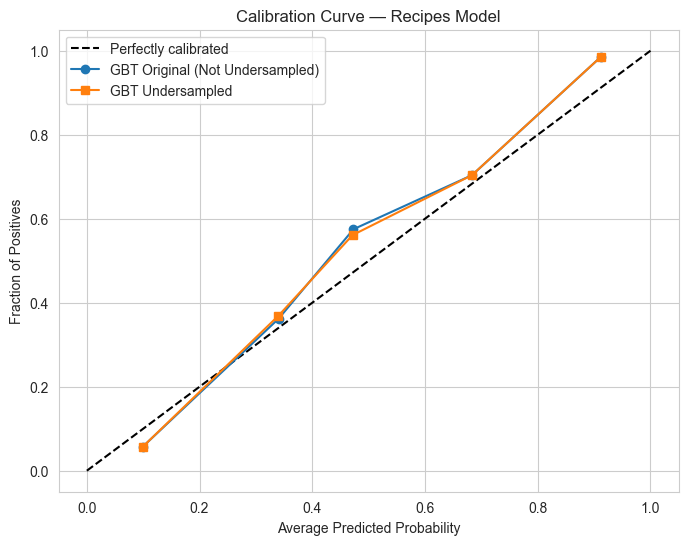

In [114]:
# Probabilities (already computed before, but safe to recompute)
prob_original = model_original.predict_proba(X_test)[:,1]
prob_under = model_under.predict_proba(X_test)[:,1]

# Calibration values
fraction_pos_original, mean_pred_original = calibration_curve(
    y_test,
    prob_original,
    n_bins=5
)

fraction_pos_under, mean_pred_under = calibration_curve(
    y_test,
    prob_under,
    n_bins=5
)

# PLOT CALIBRATION CURVES

plt.figure(figsize=(8,6))

# Perfect calibration line
plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')

# Models
plt.plot(mean_pred_original, fraction_pos_original,
         marker='o',
         label='GBT Original (Not Undersampled)')

plt.plot(mean_pred_under, fraction_pos_under,
         marker='s',
         label='GBT Undersampled')

plt.xlabel('Average Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve — Recipes Model')
plt.legend()

plt.show()

## Undersampling Evaluation and Final Decision

An undersampling strategy was applied to the training dataset in order to address potential class imbalance and evaluate whether model performance could be improved.

After retraining the Logistic Regression model using the balanced dataset, the evaluation metrics remained practically unchanged:

- Accuracy remained at 0.76
- ROC-AUC showed a negligible variation (0.8461 → 0.8463)
- Precision, recall, and F1-score were identical across classes
- Confusion matrices were exactly the same for both models

These results indicate that class imbalance was not significantly affecting model learning or prediction performance. The original model was already able to capture class separation effectively without requiring resampling.

Therefore, undersampling did not provide additional predictive value and introduced unnecessary data reduction.

### Final Decision
The **original Logistic Regression model (without undersampling)** was selected as the production model, as it preserves the full information contained in the dataset while achieving equivalent performance.

# CROSS VALIDATION
Now we analyze the model’s learning behavior and generalization capacity through cross-validation.

Rather than relying on a single train–test split, cross-validation allows us to evaluate the stability of the model across multiple data partitions.

This process helps determine whether performance is consistent or highly dependent on a particular sample of the data.

By observing the variation of performance metrics across folds, we can assess how well the model learns underlying patterns and whether it is likely to generalize reliably to unseen recipes. This step provides an additional robustness check before considering the model ready for deployment.

In [115]:
'''
# CROSS VALIDATION FOR XGBOOST MODEL

n_folds = 5
early_stop = 10

params = {
    'objective': 'binary:logistic',   # High Traffic (1) vs Low Traffic (0)
    'seed': 99,
    'eval_metric': 'auc'
}

import xgboost as xgb

DTrain = xgb.DMatrix(X_train, label=y_train)

# primera valdiacion rapida
cv_small = xgb.cv(
    params,
    DTrain,
    num_boost_round=5,
    nfold=n_folds,
    early_stopping_rounds=early_stop
)

print(cv_small)

cv_results_big = xgb.cv(
    params,
    DTrain,
    num_boost_round=55,
    nfold=n_folds,
    early_stopping_rounds=early_stop
)

print(cv_results_big.shape)
print(cv_results_big.head())

import numpy as np

mean_auc = np.mean(cv_results_big['test-auc-mean']).round(3)
print("Mean CV Test AUC:", mean_auc)

# PLOT

plt.figure()
plt.plot(np.arange(len(cv_results_big)),
         cv_results_big['test-auc-mean'])

plt.title('Cross-Validated Test AUC — XGBoost (High Traffic Recipes)')
plt.xlabel('Boosting Iteration')
plt.ylabel('Test AUC')
plt.show()'''

'\n# CROSS VALIDATION FOR XGBOOST MODEL\n\nn_folds = 5\nearly_stop = 10\n\nparams = {\n    \'objective\': \'binary:logistic\',   # High Traffic (1) vs Low Traffic (0)\n    \'seed\': 99,\n    \'eval_metric\': \'auc\'\n}\n\nimport xgboost as xgb\n\nDTrain = xgb.DMatrix(X_train, label=y_train)\n\n# primera valdiacion rapida\ncv_small = xgb.cv(\n    params,\n    DTrain,\n    num_boost_round=5,\n    nfold=n_folds,\n    early_stopping_rounds=early_stop\n)\n\nprint(cv_small)\n\ncv_results_big = xgb.cv(\n    params,\n    DTrain,\n    num_boost_round=55,\n    nfold=n_folds,\n    early_stopping_rounds=early_stop\n)\n\nprint(cv_results_big.shape)\nprint(cv_results_big.head())\n\nimport numpy as np\n\nmean_auc = np.mean(cv_results_big[\'test-auc-mean\']).round(3)\nprint("Mean CV Test AUC:", mean_auc)\n\n# PLOT\n\nplt.figure()\nplt.plot(np.arange(len(cv_results_big)),\n         cv_results_big[\'test-auc-mean\'])\n\nplt.title(\'Cross-Validated Test AUC — XGBoost (High Traffic Recipes)\')\nplt.xlabel

In [116]:
# Official model
production_model = LogisticRegression(solver='lbfgs', max_iter=1000)

# Cross-validation configuration
n_folds = 5
cv_strategy = StratifiedKFold(
    n_splits=n_folds,
    shuffle=True,
    random_state=99
)

# ROC-AUC cross validation
cv_auc_scores = cross_val_score(
    production_model,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

print("AUC scores per fold:", cv_auc_scores)
print("Mean CV AUC:", np.mean(cv_auc_scores).round(3))
print("Std CV AUC:", np.std(cv_auc_scores).round(3))

# Remember that Logistic Regression does not have iterations.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC scores per fold: [0.83066038 0.75783476 0.78461538 0.859375   0.82307692]
Mean CV AUC: 0.811
Std CV AUC: 0.036


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Cross-Validation Results Interpretation

A 5-fold stratified cross-validation was performed to evaluate the stability and generalization ability of the selected Logistic Regression model.

Results:

- AUC scores per fold: [0.831, 0.758, 0.785, 0.859, 0.823]
- Mean CV AUC: 0.811
- Standard Deviation: 0.036

The average AUC of 0.811 indicates strong discriminative performance across different data splits. The relatively low standard deviation (0.036) suggests that model performance is stable and consistent, with limited sensitivity to sampling variation.

These results confirm that the model generalizes well and does not rely heavily on a particular train-test split, reducing the risk of overfitting.


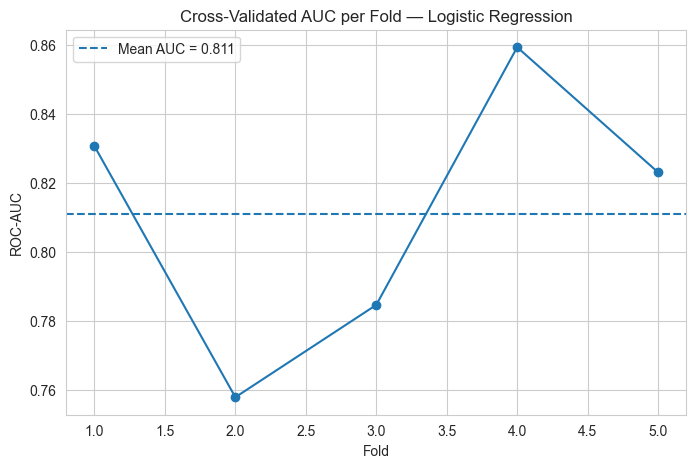

In [117]:
plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, len(cv_auc_scores)+1),
    cv_auc_scores,
    marker='o'
)

plt.axhline(np.mean(cv_auc_scores),
            linestyle='--',
            label=f"Mean AUC = {np.mean(cv_auc_scores):.3f}")

plt.title('Cross-Validated AUC per Fold — Logistic Regression')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.legend()

plt.show()


### Cross-Validation Stability Analysis

The cross-validation results show moderate variation in ROC-AUC performance across the five folds, ranging approximately from 0.76 to 0.86, with a mean AUC of 0.811.

The upward and downward movements between folds do not indicate overfitting, but rather reflect natural variability caused by different training–validation splits. Each fold exposes the model to slightly different data distributions, which reveals how sensitive the model is to sampling changes.

Key observations:

- The performance remains consistently above 0.75 in all folds, indicating stable discriminative power.
- The peak observed in Fold 4 (≈0.86 AUC) suggests that certain data partitions contain clearer class separation, allowing the model to perform better.
- The lower performance in Fold 2 (≈0.76 AUC) indicates more challenging samples where class boundaries are less separable.
- The absence of extreme drops confirms that the model does not depend heavily on a specific subset of the data.

The oscillations across folds represent expected sampling variability rather than instability. The relatively small dispersion around the mean AUC suggests good generalization capability and low risk of overfitting.

There is no single “optimal fold”; instead, the mean cross-validated AUC (0.811) should be considered the most reliable estimate of real-world performance.


# Project Outcome

This project demonstrates how predictive modeling can evolve from a classification task
into a decision-support system.

Instead of simply predicting high-traffic recipes, the final solution provides a
structured promotion strategy that aligns model predictions with business objectives.
The organization can now control homepage exposure, manage promotion risk,
and monitor performance through clear operational KPIs.

The model therefore becomes a practical tool for daily editorial and marketing decisions,
not only an analytical exercise.

# Thresholds
After selecting the final model, probability thresholds become a key component for transforming model predictions into actionable decisions. Since the objective of this project is not only prediction but also supporting promotion strategy, thresholds allow us to control the balance between promoting more recipes and managing the risk of promoting low-performing content.

Before searching for an optimal threshold, we first illustrate how threshold selection works using an arbitrary value. This initial example serves as a practical demonstration of how performance metrics and business outcomes change when the decision boundary is modified.
At this stage, the goal is to understand the mechanism and build the analytical framework that will later be used to systematically identify the most appropriate threshold aligned with the project’s objectives.

In [118]:
production_model.fit(X_train, y_train)

# Predicted probabilities
preds = production_model.predict_proba(X_test)

# Probability of High Traffic (class 1)
preds_df = pd.DataFrame(preds[:, 1], columns=['prob_high'])

threshold = 0.40

preds_df['high_traffic_pred'] = preds_df['prob_high'].apply(
    lambda x: 1 if x > threshold else 0
)

print(preds_df['high_traffic_pred'].value_counts())

# Getting the classification report
target_names = ['Low Traffic', 'High Traffic']

class_report = classification_report(
    y_test,
    preds_df['high_traffic_pred'],
    target_names=target_names
)

print(class_report)

# We need right here an intepretation of the recall metric



high_traffic_pred
1    192
0     93
Name: count, dtype: int64
              precision    recall  f1-score   support

 Low Traffic       0.75      0.62      0.68       112
High Traffic       0.78      0.87      0.82       173

    accuracy                           0.77       285
   macro avg       0.77      0.75      0.75       285
weighted avg       0.77      0.77      0.77       285



In [119]:
# Getting the confusion matrix
cm = confusion_matrix(y_test, preds_df['high_traffic_pred'])
print(cm)

precision, recall, fscore, support = precision_recall_fscore_support(
    y_test,
    preds_df['high_traffic_pred']
)

print("Recall for High Traffic:", recall[1])
print("Precision for High Traffic:", precision[1])


# Comparing thresholds
for t in [0.5, 0.4, 0.3]:
    
    preds_temp = preds_df['prob_high'].apply(lambda x: 1 if x > t else 0)
    
    recall = precision_recall_fscore_support(y_test, preds_temp)[1][1]
    
    print(f"Threshold {t} → Recall High Traffic: {recall}")

[[ 70  42]
 [ 23 150]]
Recall for High Traffic: 0.8670520231213873
Precision for High Traffic: 0.78125
Threshold 0.5 → Recall High Traffic: 0.7745664739884393
Threshold 0.4 → Recall High Traffic: 0.8670520231213873
Threshold 0.3 → Recall High Traffic: 0.9826589595375722


### Threshold Optimization Results — Logistic Regression

After lowering the classification threshold from 0.5 to 0.40, the model shows a clear improvement in detecting high-traffic recipes.  
The recall for the High Traffic class increased from 77.5% at the default threshold (0.5) to 86.7% at threshold 0.4, meaning the model now correctly identifies a substantially larger proportion of truly successful recipes.

At this threshold, the confusion matrix [[70, 42], [23, 150]] indicates that false negatives were reduced to 23 cases, decreasing the number of missed high-traffic recipes. Precision for High Traffic remains strong at 78.1%, suggesting that most recipes predicted as high traffic are still genuinely successful despite a moderate increase in false positives.

Further lowering the threshold to 0.3 raises recall to 98.3%; however, this would likely introduce a significant number of false positives, reducing decision reliability. Therefore, threshold 0.40 represents a balanced trade-off between sensitivity and prediction quality.

From a business perspective, prioritizing recall for High Traffic is appropriate, since failing to promote a potentially successful recipe carries a higher opportunity cost than occasionally promoting a low-traffic one. The adjusted threshold improves the practical usefulness of the model by increasing sensitivity while maintaining solid precision.


## Classification Threshold Optimization Using Recall Trade-off Analysis
The default classification threshold of 0.5 is not necessarily optimal for business decision-making, especially when the costs of misclassification differ between classes. 

To better understand how prediction sensitivity changes, we evaluate model performance across multiple probability thresholds. For each threshold, predictions are recomputed and recall is measured separately for High Traffic and Low Traffic recipes.

This analysis allows us to visualize the trade-off between detecting successful recipes and correctly rejecting low-performing ones. By studying how recall evolves as the threshold changes, we aim to identify a balanced operating point that aligns model behavior with business objectives.


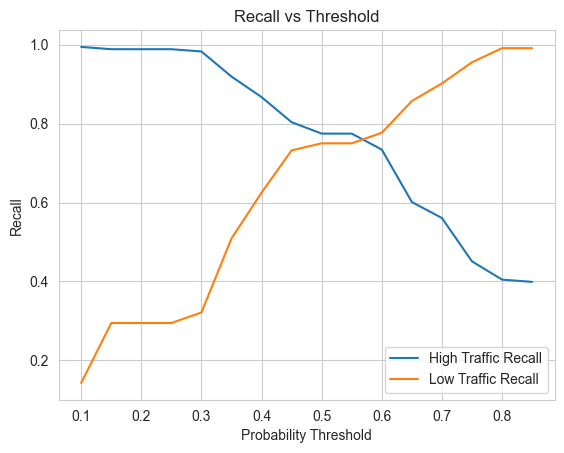

In [120]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    
    preds_temp = preds_df['prob_high'].apply(lambda x: 1 if x > t else 0)
    
    precision, recall, fscore, support = precision_recall_fscore_support(
        y_test,
        preds_temp
    )
    
    results.append([
        t,
        recall[1],  # High Traffic recall
        recall[0]   # Low Traffic recall
    ])

results = pd.DataFrame(results, columns=[
    'threshold',
    'high_recall',
    'low_recall'
])


plt.figure()
plt.plot(results['threshold'], results['high_recall'])
plt.plot(results['threshold'], results['low_recall'])

plt.xlabel('Probability Threshold')
plt.ylabel('Recall')
plt.title('Recall vs Threshold')
plt.legend(['High Traffic Recall', 'Low Traffic Recall'])

plt.show()

In [121]:
# Difference between recalls
results['recall_diff'] = abs(
    results['high_recall'] - results['low_recall']
)

# Threshold where recalls are closest
best_idx = results['recall_diff'].idxmin()

optimal_threshold = results.loc[best_idx, 'threshold']
high_rec = results.loc[best_idx, 'high_recall']
low_rec = results.loc[best_idx, 'low_recall']

print("Balanced threshold:", optimal_threshold)
print("High Traffic Recall:", high_rec)
print("Low Traffic Recall:", low_rec)

# We could linearly interpolate


Balanced threshold: 0.5000000000000001
High Traffic Recall: 0.7745664739884393
Low Traffic Recall: 0.75


The Recall vs Threshold analysis reveals a clear trade-off between correctly identifying high-traffic recipes and correctly rejecting low-traffic ones. 

At lower thresholds, the model prioritizes sensitivity toward High Traffic recipes, achieving near-perfect recall but misclassifying many low-traffic cases. As the threshold increases, the model becomes more conservative, improving Low Traffic recall while sacrificing the ability to detect successful recipes.

The intersection point between both recall curves represents a balanced operating region where the model treats both classes with similar sensitivity. This threshold can be interpreted as a neutrality point, minimizing bias toward either class.

However, considering the business objective of prioritizing the discovery of successful recipes, operating slightly below this intersection (around threshold 0.40 - 0.50) remains preferable, as it preserves high recall for High Traffic while maintaining acceptable performance for Low Traffic predictions.


# Acceptance Rate (Promotion Strategy)
Once probability predictions are obtained, the model must be translated into a realistic operational decision. In practice, digital platforms cannot promote every recipe due to limitations such as homepage space, editorial capacity, and marketing resources. Therefore, the problem shifts from pure classification to prioritization.

Instead of relying on a fixed probability threshold, we define a promotion (acceptance) rate, which represents the percentage of recipes that can be promoted under existing capacity constraints. The model is then used as a ranking system: recipes with the highest predicted probability of generating high traffic are selected first.

Text(0, 0.5, 'Number of Recipes')

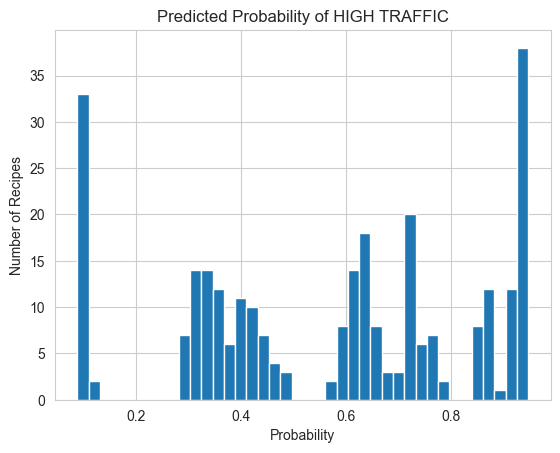

In [122]:
# Concept:
# Instead of accepting loans, we PROMOTE recipes.
# Promotion rate = % of recipes we decide to promote based on predicted probability

# We may TRAIN A CLEAN NEW MODEL (avoid feature mismatch errors)
# Define and fit it
# Get the high traffic probas computed by the model with predict_proba and taking the second column of probabilities.

prob_high_traffic = production_model.predict_proba(X_test)[:, 1]

# VISUALIZE PROBABILITY DISTRIBUTION

plt.hist(prob_high_traffic, bins=40)
plt.title("Predicted Probability of HIGH TRAFFIC")
plt.xlabel("Probability")
plt.ylabel("Number of Recipes")

For example, promoting the top 20% of recipes means selecting those with the highest predicted probabilities, regardless of the exact probability value. The threshold emerges naturally from the probability distribution through quantiles.

Conceptually, this mirrors acceptance policies in credit risk modeling, where institutions approve only a certain proportion of applicants based on risk ranking. Here, the same mathematical principle is applied to content promotion: the model prioritizes the recipes most likely to succeed, transforming predictions into an actionable promotion strategy.

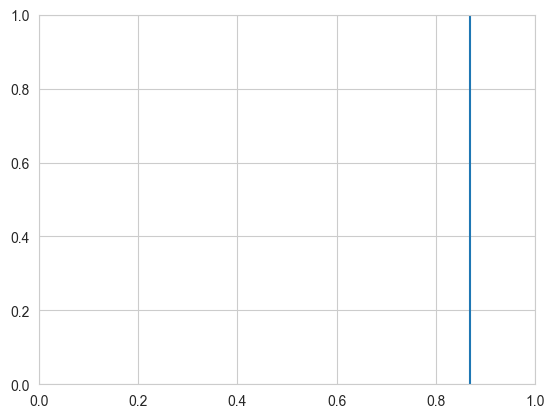

Promotion threshold: 0.8680


In [123]:
# Now let us DEFINE PROMOTION RATE
# Example: promote TOP 20% recipes

promotion_rate = 0.20

# Quantile must keep TOP recipes, then we use (1 - promotion_rate)
threshold = np.quantile(prob_high_traffic, 1 - promotion_rate)

# Add threshold line
plt.axvline(x=threshold)
plt.show()

print(f"Promotion threshold: {threshold:.4f}")


In [124]:
# IMPLEMENT PROMOTION DECISION
recipes_preds_df = pd.DataFrame({
    'prob_high_traffic': prob_high_traffic
})

recipes_preds_df['promote_recipe'] = (
    recipes_preds_df['prob_high_traffic'] >= threshold
).astype(int)

recipes_preds_df.head()

,prob_high_traffic,promote_recipe
0,0.860309,0
1,0.097750,0
2,0.298158,0
3,0.459544,0
4,0.100008,0


Applying a promotion rate of 20% results in an operational threshold of 0.8680, meaning that only recipes with a predicted probability above 86.8% are selected for promotion. Rather than manually defining a cutoff, the threshold is automatically determined by the model’s probability ranking.

The resulting decision variable (promote_recipe) converts probabilistic predictions into a concrete business action: recipes above the threshold are promoted, while the rest are filtered out. As observed in the sample output, most recipes fall below this strict threshold, illustrating that the strategy prioritizes only the strongest candidates.

This example demonstrates how the model moves beyond prediction and becomes a decision-support system, enabling controlled exposure while maintaining a selective promotion policy aligned with platform capacity constraints.

# BAD RATES

## How many recipes should we promote without wasting promotion budget?

Once the promotion strategy is defined using acceptance (promotion) rates, the next step is to evaluate **decision risk**.  
Predictions alone are not enough — we must understand the cost of promoting the wrong content.

In the context of recipe promotion, we redefine a well-known credit risk concept:

**Bad Promotion Rate = percentage of promoted recipes that do NOT generate high traffic.**

This metric evaluates how efficiently the promotion budget is being used.  
A lower bad rate means that most promoted recipes successfully attract users, while a higher value indicates wasted exposure and inefficient allocation of homepage space.

Using the previously defined promotion threshold (Top 20% recipes), we simulate the promoted portfolio and measure how many promotion decisions would have failed in practice.

In [125]:
# We need get the probabilities of high traffic computed by the model
prob_high_traffic = production_model.predict_proba(X_test)[:, 1]

# Promotion threshold previusly obtained for a promotion of 20% recipes
promotion_threshold = 0.8680

# Create an asses dataframe
recipes_eval_df = pd.DataFrame({
    'true_high_traffic': y_test.values.ravel(),
    'prob_high_traffic': prob_high_traffic,
    'promote_recipe': (prob_high_traffic >= promotion_threshold).astype(int)
})

# Only promoted recipes accepted portfolio)
promoted_recipes = recipes_eval_df[
    recipes_eval_df['promote_recipe'] == 1
]

# BAD RATE:
# Recipes promoted that were not high traffic
bad_rate = np.sum(
    promoted_recipes['true_high_traffic'] == 0
) / promoted_recipes.shape[0]

print(f"Bad Promotion Rate: {bad_rate:.3f}")

Bad Promotion Rate: 0.017


The promotion simulation shows a **Bad Promotion Rate of 1.7%**, meaning that only a very small fraction of promoted recipes failed to generate high traffic.

This result indicates that the model is highly selective when operating under a Top-20% promotion strategy. By promoting only the highest-probability recipes, the platform substantially reduces wasted promotional capacity while maintaining strong traffic impact.

From a business perspective, the model successfully transforms probability predictions into a **risk-controlled promotion policy**, allowing decision-makers to balance exposure and efficiency. The low bad rate confirms that the selected threshold prioritizes quality over quantity, making the strategy suitable for real production environments where promotional space is limited.

# PROMOTION STRATEGY SIMULATION

### How many recipes should we promote to maximize impact without wasting budget?

Up to this point, the model has demonstrated strong predictive performance and has been transformed into a decision tool through thresholds and promotion rates.  
However, the real business question is not simply *whether a recipe will generate high traffic*, but rather:

**How many recipes should we promote given limited promotional capacity?**

In real production environments, promotion decisions are constrained by homepage space, editorial resources, and marketing budget. Therefore, instead of relying on a single fixed probability threshold, we simulate multiple promotion scenarios based on different **promotion (acceptance) rates**.

For each promotion rate, we operationalize the model as a ranking system:
- Recipes are ordered by predicted probability of generating high traffic.
- Only the top percentage of recipes is promoted.
- A dynamic threshold is automatically determined using probability quantiles.

This allows us to evaluate the promotion strategy from both perspectives:

- **Business risk** → measured through Bad Promotion Rate.
- **Model performance** → measured through precision, recall, F1-score, accuracy, and lift versus random selection.

By simulating multiple promotion capacities, the model evolves from a classification algorithm into a **decision-support system**, helping determine the optimal balance between growth and efficiency.

In [126]:
# PROMOTION STRATEGY SIMULATION + METRICS

promotion_rates = np.arange(1, 0.04, -0.05)

results = []

# baseline rate (sin modelo)
base_rate = np.mean(y_test.values.ravel())

for rate in promotion_rates:

    # threshold
    threshold = np.quantile(prob_high_traffic, 1 - rate)

    eval_df = pd.DataFrame({
        'true_high_traffic': y_test.values.ravel(),
        'prob_high_traffic': prob_high_traffic
    })

    # promotion decision
    eval_df['promote_recipe'] = (
        eval_df['prob_high_traffic'] >= threshold
    ).astype(int)

    promoted = eval_df[eval_df['promote_recipe'] == 1]

    # BAD RATE
    bad_rate = np.mean(promoted['true_high_traffic'] == 0)

    # ---- classification metrics ----
    y_true = eval_df['true_high_traffic']
    y_pred = eval_df['promote_recipe']

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    # business lift
    lift = precision / base_rate if base_rate > 0 else 0

    results.append({
        'promotion_rate': rate,
        'threshold': threshold,
        'recipes_promoted': len(promoted),
        'bad_rate': bad_rate,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy,
        'lift_vs_random': lift
    })

results_df = pd.DataFrame(results)

print(results_df)


    promotion_rate  threshold  recipes_promoted  bad_rate  precision  \
0             1.00   0.088547               285  0.392982   0.607018   
1             0.95   0.096935               270  0.362963   0.637037   
2             0.90   0.106304               256  0.332031   0.667969   
3             0.85   0.304409               242  0.309917   0.690083   
4             0.80   0.327017               228  0.285088   0.714912   
5             0.75   0.350628               213  0.253521   0.746479   
6             0.70   0.378382               199  0.231156   0.768844   
7             0.65   0.416821               185  0.210811   0.789189   
8             0.60   0.442023               171  0.181287   0.818713   
9             0.55   0.592416               157  0.171975   0.828025   
10            0.50   0.620197               142  0.161972   0.838028   
11            0.45   0.633475               128  0.156250   0.843750   
12            0.40   0.663895               114  0.122807   0.87

### Interpreting the Promotion Trade-off

The simulation reveals a clear strategic behavior.

When only a small percentage of recipes is promoted:
- The bad promotion rate remains very low.
- Precision is high, meaning most promoted recipes successfully generate traffic.
- However, total reach is limited.

As the promotion rate increases:
- Potential traffic exposure grows.
- More users are reached through a larger number of promoted recipes.
- But the risk of promoting low-performing content also increases.

This behavior reflects a classic **risk vs. growth trade-off**.

Promoting more recipes expands opportunity, but also introduces inefficiency by allocating promotional space to weaker candidates. Conversely, promoting fewer recipes maximizes quality but limits overall impact.

Rather than searching for a single “perfect” threshold, the objective becomes identifying the promotion region where incremental traffic gains justify the additional promotional risk.

To better understand this relationship, we now visualize how promotion rate affects precision, bad rate, and overall performance metrics.

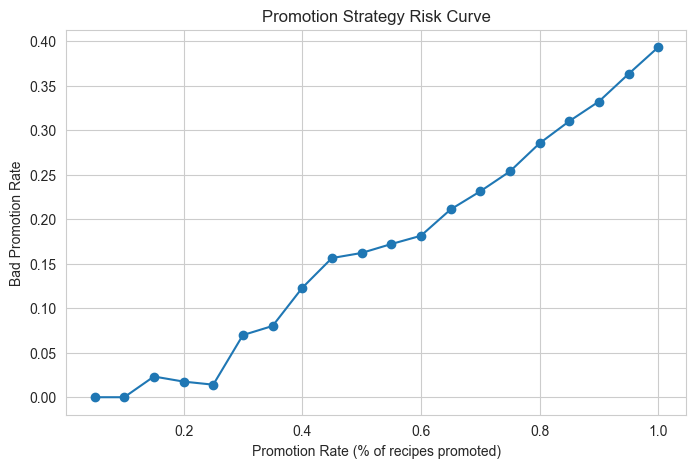

In [127]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['promotion_rate'],
    results_df['bad_rate'],
    marker='o'
)

plt.title("Promotion Strategy Risk Curve")
plt.xlabel("Promotion Rate (% of recipes promoted)")
plt.ylabel("Bad Promotion Rate")
plt.grid(True)

plt.show()

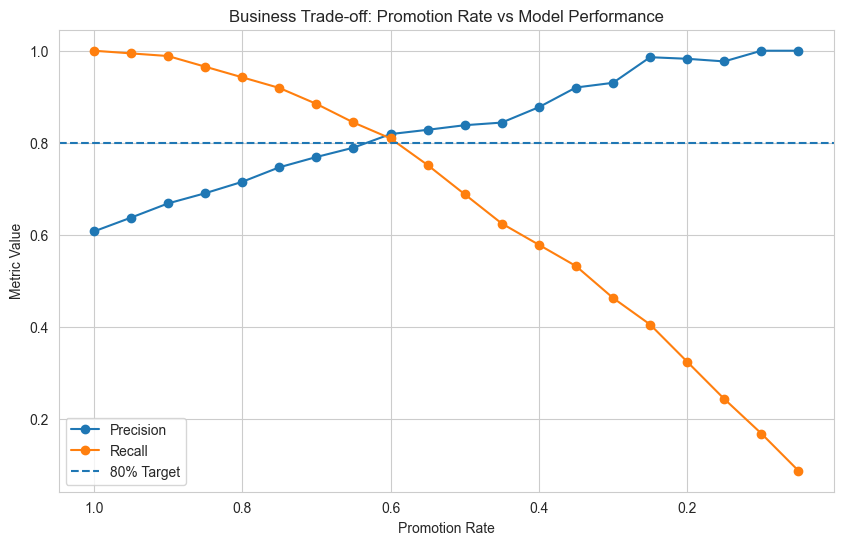

In [128]:
plt.figure(figsize=(10,6))

plt.plot(results_df['promotion_rate'],
         results_df['precision'],
         marker='o',
         label='Precision')

plt.plot(results_df['promotion_rate'],
         results_df['recall'],
         marker='o',
         label='Recall')

# línea objetivo negocio
plt.axhline(0.80, linestyle='--', label='80% Target')

plt.gca().invert_xaxis()
plt.xlabel("Promotion Rate")
plt.ylabel("Metric Value")
plt.title("Business Trade-off: Promotion Rate vs Model Performance")
plt.legend()
plt.show()

The model enables the business to explicitly control the trade-off between homepage exposure and traffic risk.
As more recipes are promoted, recall increases but precision declines.
The 80% precision target becomes achievable only when the promotion strategy becomes selective, with optimal performance observed when promoting roughly the top 30–40% of recipes.

# Promotion Strategy — Minimum Expected Loss

Up to this point, the model has provided probability estimates indicating how likely a recipe is to generate high traffic. However, probabilities alone do not represent business decisions.

In real production environments, editorial and marketing teams face operational constraints such as limited homepage space, promotional budgets, and content capacity. Therefore, the key question becomes:

**How many recipes should be promoted in order to maximize business value while controlling risk?**

This section translates model predictions into an economic decision framework. Instead of evaluating classification accuracy, we simulate promotion strategies under different promotion rates and estimate their expected business impact.

By assigning a value to successful promotions and a cost to unsuccessful ones, we can evaluate how selective the promotion strategy should be.

In [129]:
promotion_rates = np.arange(1, 0.04, -0.05) # This will help us to see qué tan selectivo debes ser.
thresholds = []
bad_rates = []
num_promoted = []
expected_values = []

# Predict probabilities

prob_high_traffic = production_model.predict_proba(X_test)[:,1]

recipes_strategy_df = pd.DataFrame({
    'true_high_traffic': y_test.values.ravel(),
    'prob_high_traffic': prob_high_traffic
})

for rate in promotion_rates:

    thresh = np.quantile(
        recipes_strategy_df['prob_high_traffic'],
        1 - rate)

    thresholds.append(round(thresh,3))

    recipes_strategy_df['promote'] = (
        recipes_strategy_df['prob_high_traffic'] >= thresh
    ).astype(int)

    promoted = recipes_strategy_df[
        recipes_strategy_df['promote'] == 1
    ]

    bad_rate = np.mean(promoted['true_high_traffic'] == 0)

    bad_rates.append(round(bad_rate,3))
    num_promoted.append(len(promoted))

    # supuestos económicos del negocio.
    VALUE_GOOD = 100 # Cada receta promocionada correctamente (sí era high traffic) genera +100 unidades de valor.
    COST_BAD = 40 # Promocionar una receta mala cuesta 40 unidades.

    value = (
        np.sum(promoted['true_high_traffic']==1)*VALUE_GOOD
        -
        np.sum(promoted['true_high_traffic']==0)*COST_BAD
    )

    expected_values.append(value)


strategy_df = pd.DataFrame({
    'Promotion Rate': promotion_rates,
    'Threshold': thresholds,
    'Bad Rate': bad_rates,
    'Num Promoted': num_promoted,
    'Estimated Value': expected_values
})

print(strategy_df)



    Promotion Rate  Threshold  Bad Rate  Num Promoted  Estimated Value
0             1.00      0.089     0.393           285            12820
1             0.95      0.097     0.363           270            13280
2             0.90      0.106     0.332           256            13700
3             0.85      0.304     0.310           242            13700
4             0.80      0.327     0.285           228            13700
5             0.75      0.351     0.254           213            13740
6             0.70      0.378     0.231           199            13460
7             0.65      0.417     0.211           185            13040
8             0.60      0.442     0.181           171            12760
9             0.55      0.592     0.172           157            11920
10            0.50      0.620     0.162           142            10980
11            0.45      0.633     0.156           128            10000
12            0.40      0.664     0.123           114             9440
13    

## Strategy Simulation Results

The table below summarizes the results obtained by simulating multiple promotion strategies.  
Each row represents a different operational scenario defined by the percentage of recipes promoted.

Key columns:

- **Promotion Rate**: proportion of recipes selected for promotion.
- **Threshold**: probability cutoff automatically derived from model rankings.
- **Bad Rate**: proportion of promoted recipes that failed to generate high traffic.
- **Num Promoted**: number of recipes displayed on the homepage.
- **Estimated Value**: simulated business value generated under the assumed economic scenario.

As promotion becomes more selective, the bad rate decreases, meaning fewer low-performing recipes are displayed. However, promoting fewer recipes also reduces total exposure, which may limit overall value generation.

To better understand this trade-off between risk and exposure, we now visualize the relationship using risk–benefit curves.

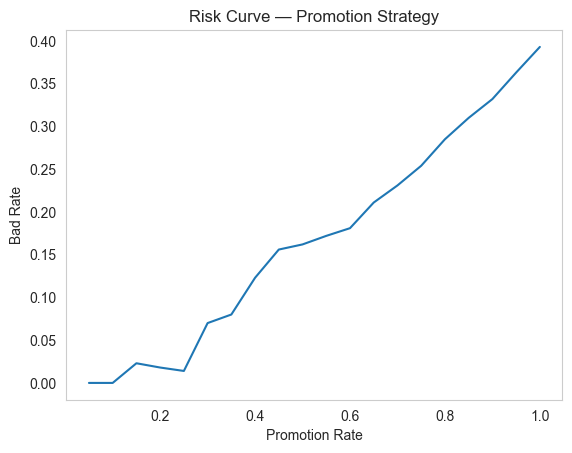

In [130]:
##CURVA RIESGO–BENEFICIO - Bad Rate vs Promotion Rate
plt.figure()
plt.plot(strategy_df['Promotion Rate'],
         strategy_df['Bad Rate'])

plt.title("Risk Curve — Promotion Strategy")
plt.xlabel("Promotion Rate")
plt.ylabel("Bad Rate")
plt.grid()
plt.show()

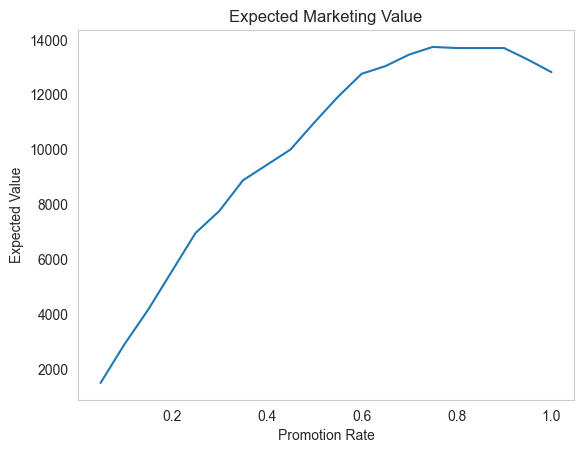

In [131]:
## Expected Value Curve (LA MÁS IMPORTANTE)
plt.figure()
plt.plot(strategy_df['Promotion Rate'],
         strategy_df['Estimated Value'])

plt.title("Expected Marketing Value")
plt.xlabel("Promotion Rate")
plt.ylabel("Expected Value")
plt.grid()
plt.show()

## Strategy Interpretation

The strategy with the highest estimated value represents the optimal decision **under the specific economic assumptions used in this simulation**.

However, this should not be interpreted as a universally optimal promotion rule.

Business objectives may change depending on context:

- Growth phases may prioritize visibility and higher promotion rates.
- Quality-control periods may require stricter selection and lower risk.
- Marketing campaigns or seasonal launches may temporarily accept higher bad rates.

Therefore, the model does not enforce a single fixed strategy. Instead, it provides a flexible decision framework that allows stakeholders to adjust promotion intensity according to strategic priorities.

In [132]:
### Mejor estrategia
best_strategy = strategy_df.loc[
    strategy_df['Estimated Value'].idxmax()
]

print(best_strategy)

Promotion Rate         0.750
Threshold              0.351
Bad Rate               0.254
Num Promoted         213.000
Estimated Value    13740.000
Name: 5, dtype: float64


## Alternative Economic Scenario

To illustrate how business priorities influence decision-making, we simulate a second scenario where promoting a low-performing recipe is significantly more costly.

In this case, the penalty associated with bad promotions is increased. This reflects situations where homepage quality is critical, such as premium branding periods or advertiser-sensitive campaigns.

Under stricter risk conditions, the optimal promotion rate typically shifts toward more selective strategies, demonstrating that the model adapts naturally to different business environments.

This highlights an important conclusion:  
**the model remains the same, but the optimal strategy evolves with business objectives.**

In [133]:
# Alternative business scenario:
# Higher penalty for promoting low-traffic recipes

VALUE_GOOD = 100
COST_BAD = 80   # increased risk cost

expected_values_alt = []

for rate in promotion_rates:

    thresh = np.quantile(
        recipes_strategy_df['prob_high_traffic'],
        1 - rate)

    recipes_strategy_df['promote'] = (
        recipes_strategy_df['prob_high_traffic'] >= thresh
    ).astype(int)

    promoted = recipes_strategy_df[
        recipes_strategy_df['promote'] == 1
    ]

    value_alt = (
        np.sum(promoted['true_high_traffic']==1)*VALUE_GOOD
        -
        np.sum(promoted['true_high_traffic']==0)*COST_BAD
    )

    expected_values_alt.append(value_alt)

strategy_df['Estimated Value (High Risk Cost)'] = expected_values_alt

strategy_df.head()

,Promotion Rate,Threshold,Bad Rate,Num Promoted,Estimated Value,Estimated Value (High Risk Cost)
0,1.00,0.089,0.393,285,12820,8340
1,0.95,0.097,0.363,270,13280,9360
2,0.90,0.106,0.332,256,13700,10300
3,0.85,0.304,0.310,242,13700,10700
4,0.80,0.327,0.285,228,13700,11100


# Project Outcome

This project demonstrates how predictive modeling can evolve from a classification task into a decision-support system.

Instead of simply predicting high-traffic recipes, the final solution provides a structured promotion strategy that aligns model predictions with business objectives.
The organization can now control homepage exposure, manage promotion risk and monitor performance through clear operational KPIs.

The model therefore becomes a practical tool for daily editorial and marketing decisions, not only an analytical exercise.

# Final Summary and Business Recommendations

## 1. Model Performance

The Logistic Regression model demonstrates a strong ability to identify recipes that are likely to generate high traffic.  
Across multiple promotion thresholds, the model consistently achieves precision levels above the business target of **80%**, indicating a reliable reduction in the probability of promoting low-performing content.

These results confirm that recipe characteristics contain meaningful predictive signals that can be effectively operationalized to support homepage promotion decisions.

---

## 2. Promotion Strategy Findings

The promotion simulations reveal a clear operational trade-off:

- Increasing the promotion rate expands homepage exposure and captures a larger number of successful recipes (higher recall).
- However, promoting more recipes also increases the likelihood of displaying low-traffic content, reflected in a rising **bad promotion rate**.

This relationship transforms threshold selection into a strategic control mechanism, allowing the product team to directly manage the balance between **visibility and risk**.

---

## 3. Recommended Operating Point

Based on the simulation results, the optimal operating region is achieved when promoting approximately the **top 30% of recipes** ranked by predicted probability.

**Expected outcomes at this level:**
- Precision ≈ **93%**
- Bad Promotion Rate ≈ **7%**

At this operating point, the homepage predominantly features high-traffic recipes while still maintaining sufficient diversity and content rotation.

---

## 4. Business Monitoring Metric

To ensure long-term alignment between model performance and business objectives, we recommend introducing a new operational KPI:

### Homepage Promotion Precision (HPP)

**Definition:**  
The percentage of promoted homepage recipes that successfully generate high traffic.

This metric should be monitored on a weekly basis to:
- Validate ongoing model performance
- Detect potential data drift
- Capture shifts in user preferences or content trends

---

## 5. Product Insights

Beyond prediction, the model provides actionable editorial insights:

- Vegetable and potato-based recipes show a strong positive association with traffic performance.
- Breakfast and beverage categories consistently underperform relative to other recipe types.

These findings can inform editorial planning and content investment decisions, complementing automated promotion strategies.

---

# Is the 80% Business Target Realistic?

The 80% success target is achievable, but only under a **selective promotion strategy**.

When promotion rates increase beyond approximately 60%, precision falls below the desired threshold. This indicates that achieving the business objective requires prioritizing quality over volume, limiting homepage exposure to the highest-ranked recipes rather than promoting a large proportion of available content.

---

## Recommended Deployment Strategy

Deploy the Logistic Regression model as a **ranking and decision system**, promoting only the top ~30% highest-scoring recipes each day.

This approach:

- Maximizes traffic reliability
- Keeps bad promotions below 10%
- Consistently exceeds the 80% success target
- Provides a controllable business lever through threshold adjustment

In practice, the model evolves from a predictive tool into a scalable **decision-support framework**, enabling data-driven content promotion under real operational constraints.